In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)




In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from skimage import color
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

In [2]:
import os
import pandas as pd
import zipfile
from google.colab import drive

# Mount Drive
drive.mount('/content/drive', force_remount=False)

# Paths
zip_path = "/content/drive/MyDrive/viechle.zip"
extract_path = "/content/dataset_v"

# Extract if needed
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Find correct BASE path
BASE = extract_path
if not os.path.exists(os.path.join(BASE, 'Train')):
    for item in os.listdir(BASE):
        if os.path.exists(os.path.join(BASE, item, 'Train')):
            BASE = os.path.join(BASE, item)
            break

print(f"BASE: {BASE}")

# Define train directory
train_dir = os.path.join(BASE, 'Train')

# Initialize lists
filepaths = []
labels = []

# Build train_df
for folder in os.listdir(train_dir):
    foldpath = os.path.join(train_dir, folder)
    if os.path.isdir(foldpath):
        for file in os.listdir(foldpath):
            filepaths.append(os.path.join(foldpath, file))
            labels.append(int(folder))

train_df = pd.DataFrame({
    'filepath': filepaths,
    'label': labels
})

# Build test_df
test_csv_path = os.path.join(BASE, 'Test.csv')
test_csv = pd.read_csv(test_csv_path)

test_df = pd.DataFrame({
    'filepath': test_csv['Path'].apply(lambda p: os.path.join(BASE, p)),
    'label': test_csv['ClassId'].astype(int)
})

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Mounted at /content/drive
BASE: /content/dataset_v
Train size: 39209
Test size: 12630


DIVIDE THE Train df

In [3]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size : {len(train_df)}")
print(f"Val size : {len(val_df)}")
print(f"Test size : {len(test_df)}")

Train size : 31367
Val size : 7842
Test size : 12630


In [4]:
CLASS_NAMES = {
    0:'Speed limit 20',    1:'Speed limit 30',     2:'Speed limit 50',
    3:'Speed limit 60',    4:'Speed limit 70',     5:'Speed limit 80',
    6:'End speed 80',      7:'Speed limit 100',    8:'Speed limit 120',
    9:'No passing',       10:'No passing >3.5t',  11:'Right of way jn.',
   12:'Priority road',    13:'Yield',              14:'Stop',
   15:'No vehicles',      16:'No veh >3.5t',      17:'No entry',
   18:'General caution',  19:'Danger curve L',     20:'Danger curve R',
   21:'Double curve',     22:'Bumpy road',         23:'Slippery road',
   24:'Narrow road R',    25:'Road works',         26:'Traffic signals',
   27:'Pedestrians',      28:'Children crossing',  29:'Bicycles crossing',
   30:'Beware of ice',    31:'Wild animals',       32:'End restrictions',
   33:'Turn right ahead', 34:'Turn left ahead',    35:'Ahead only',
   36:'Ahead or right',   37:'Ahead or left',      38:'Keep right',
   39:'Keep left',        40:'Roundabout',         41:'End no passing',
   42:'End no pass >3.5t'
}

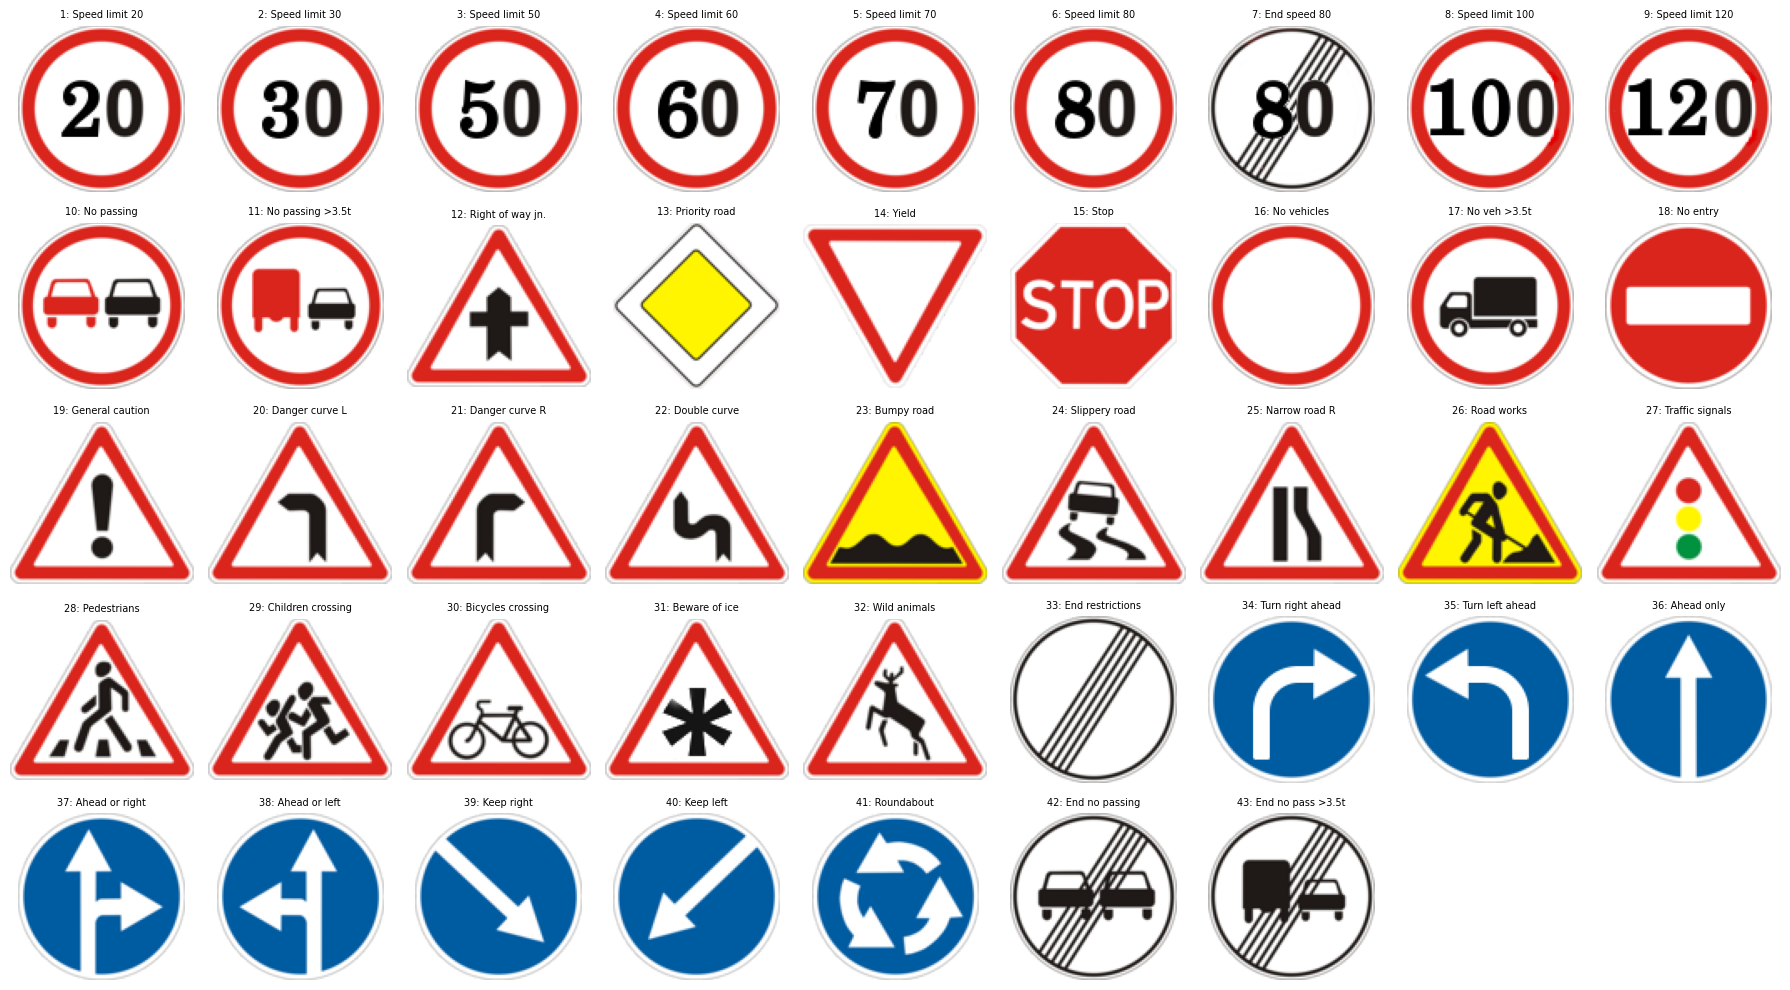

In [5]:
meta_path = os.path.join(BASE, "Meta")

fig, axes = plt.subplots(5, 9, figsize=(18, 10))
axes = axes.flatten()

for class_id in range(43):
    img_path = os.path.join(meta_path, f"{class_id}.png")
    img = Image.open(img_path)

    axes[class_id].imshow(img)
    axes[class_id].set_title(f"{class_id+1}: {CLASS_NAMES[class_id]}", fontsize=7)
    axes[class_id].axis("off")


for i in range(43, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

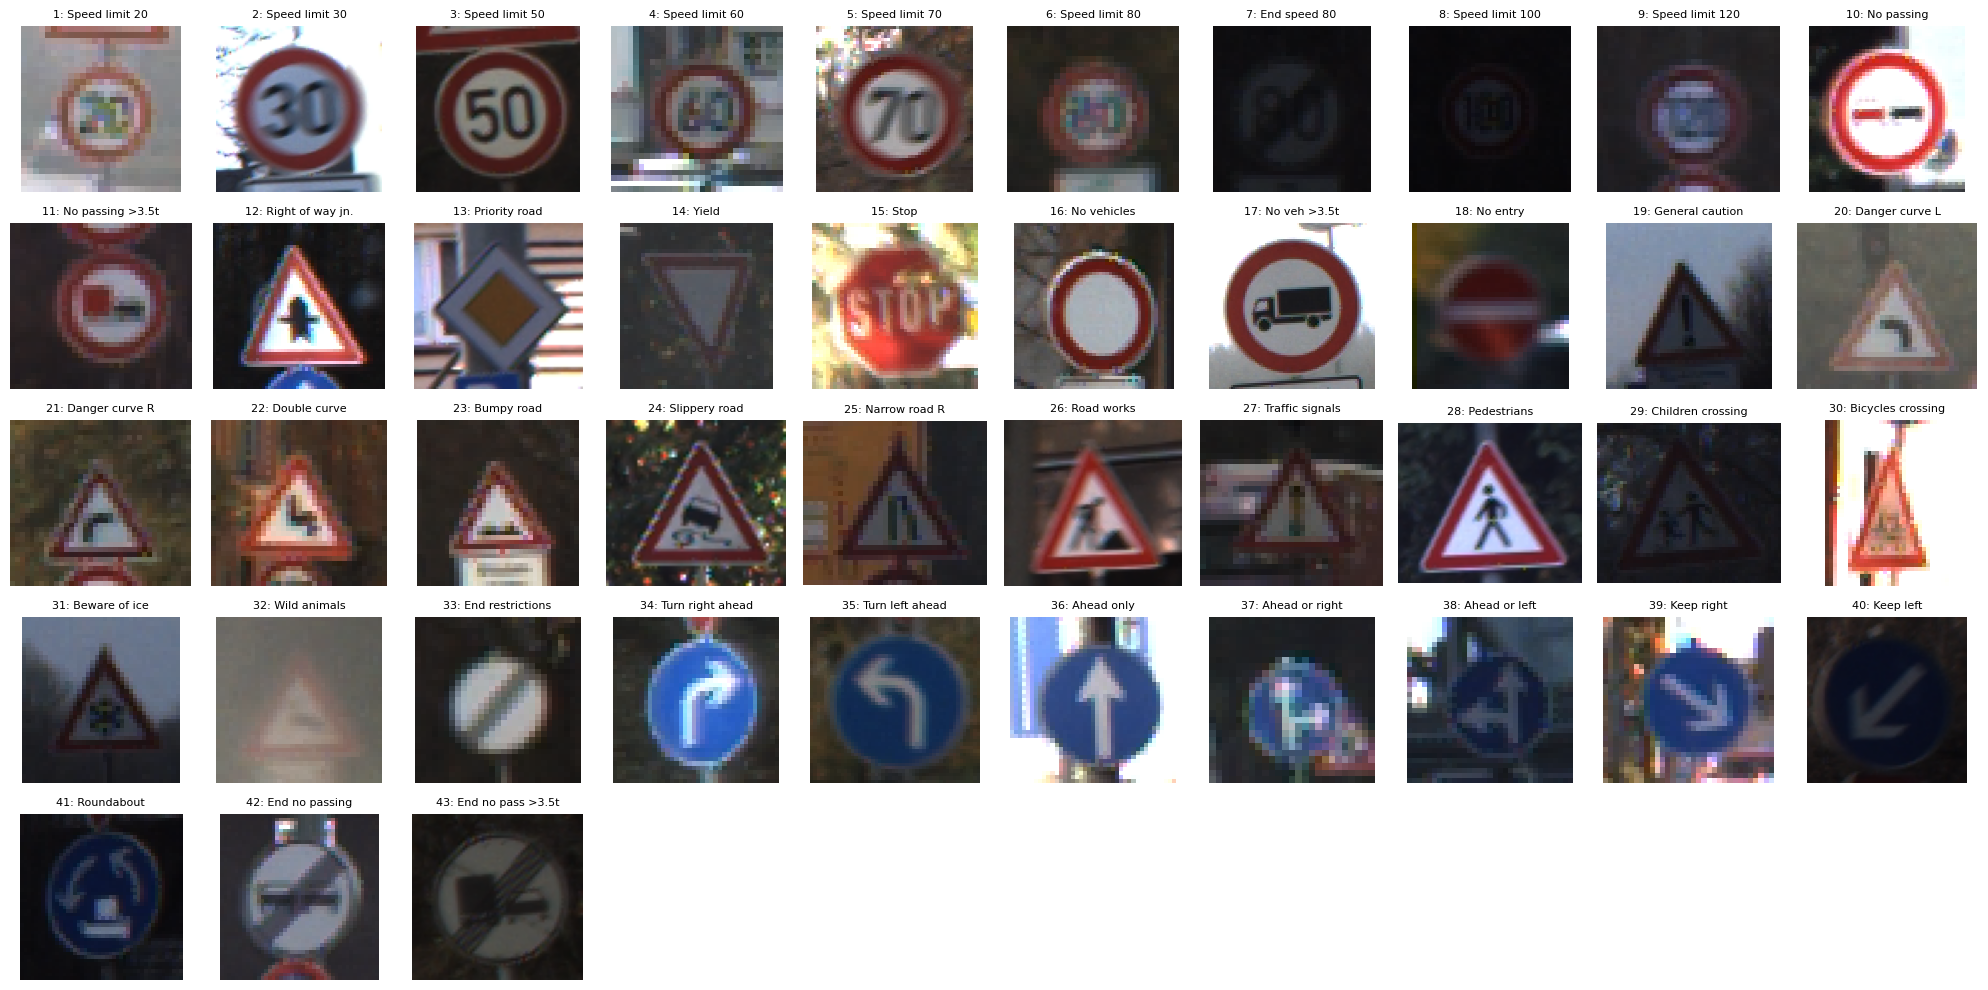

In [6]:
sample_df = train_df.groupby('label').first().reset_index()

n_samples = len(sample_df)

n_cols = 10
n_rows = (n_samples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for i in range(n_samples):
    img = Image.open(sample_df['filepath'][i])

    label = sample_df['label'][i]
    class_name = CLASS_NAMES[label]

    axes[i].imshow(img)
    axes[i].set_title(f"{label+1}: {class_name}", fontsize=8)
    axes[i].axis('off')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4716/587783984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


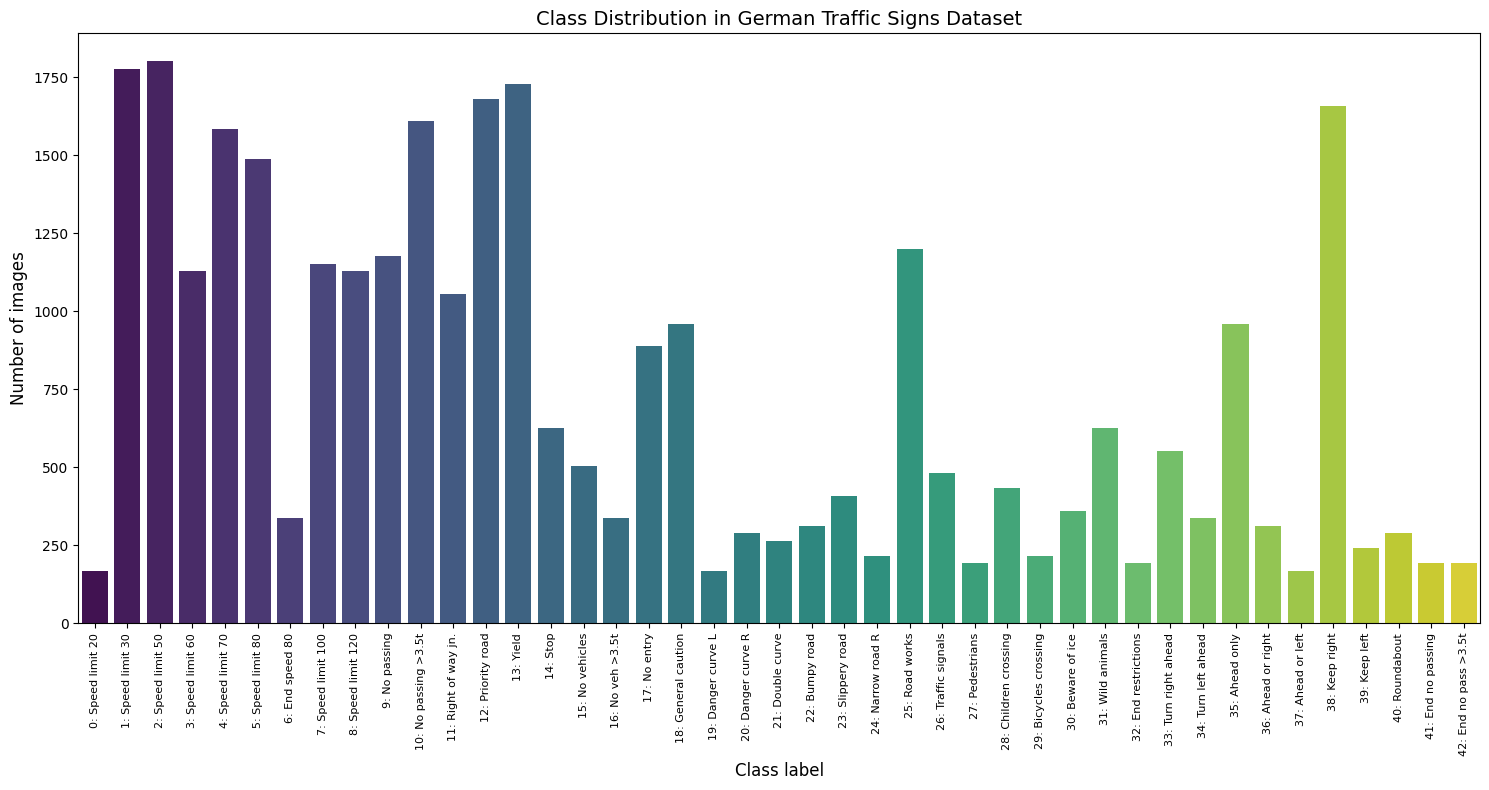

Total images: 31367
Total classes: 43
Average images per class: 729.47
Min images in a class: 168
Max images in a class: 1800


In [7]:
class_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Class label', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.title('Class Distribution in German Traffic Signs Dataset', fontsize=14)

plt.xticks(ticks=range(len(class_counts)),
           labels=[f"{i}: {CLASS_NAMES[i]}" for i in class_counts.index],
           rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

print(f"Total images: {len(train_df)}")
print(f"Total classes: {len(class_counts)}")
print(f"Average images per class: {len(train_df)/len(class_counts):.2f}")
print(f"Min images in a class: {class_counts.min()}")
print(f"Max images in a class: {class_counts.max()}")

In [ ]:
import numpy as np
from PIL import Image
from skimage import color
from skimage.feature import hog
from multiprocessing import Pool, cpu_count

def preprocess_image(image_path, size=(32, 32)):
    img = Image.open(image_path).resize(size)
    return np.array(img)

def extract_hog_features(image_array,
                         pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2),
                         orientations=8):
    img_gray = color.rgb2gray(image_array)
    fd = hog(img_gray,
             orientations=orientations,
             pixels_per_cell=pixels_per_cell,
             cells_per_block=cells_per_block,
             block_norm='L2-Hys',
             transform_sqrt=True,
             feature_vector=True)
    return fd

def process_image(filepath):
    img_array = preprocess_image(filepath)
    return extract_hog_features(img_array)

def build_hog_features(df, n_workers=None):
    filepaths = df['filepath'].tolist()
    n_workers = n_workers or cpu_count()

    with Pool(n_workers) as pool:
        features = pool.map(process_image, filepaths)

    return np.array(features)


x_train_hog = build_hog_features(train_df)
x_val_hog   = build_hog_features(val_df)
x_test_hog  = build_hog_features(test_df)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f"HOG feature size : {x_train_hog.shape[1]}")
print(f"Train HOG : {x_train_hog.shape}")
print(f"Val HOG : {x_val_hog.shape}")
print(f"Test HOG : {x_test_hog.shape}")

HOG feature size : 288
Train HOG : (31367, 288)
Val HOG : (7842, 288)
Test HOG : (12630, 288)


In [ ]:
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

In [ ]:
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train_hog)
x_val_s  = scaler.transform(x_val_hog)
x_test_s  = scaler.transform(x_test_hog)

In [ ]:
save_path = "features"
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "x_train.npy"),        x_train_hog)
np.save(os.path.join(save_path, "x_val.npy"),          x_val_hog)
np.save(os.path.join(save_path, "x_test.npy"),         x_test_hog)
np.save(os.path.join(save_path, "y_train.npy"),        y_train)
np.save(os.path.join(save_path, "y_val.npy"),          y_val)
np.save(os.path.join(save_path, "y_test.npy"),         y_test)
np.save(os.path.join(save_path, "x_train_scaled.npy"), x_train_s)
np.save(os.path.join(save_path, "x_val_scaled.npy"),   x_val_s)
np.save(os.path.join(save_path, "x_test_scaled.npy"),  x_test_s)

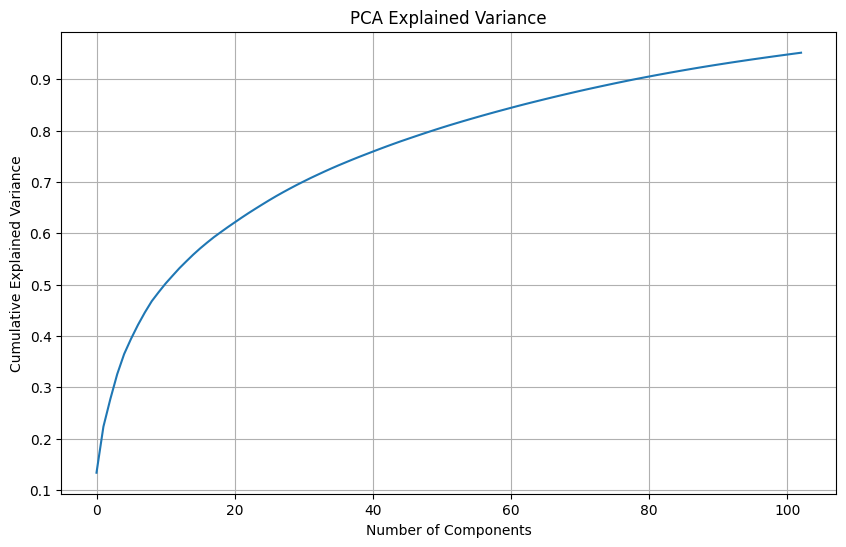

Components selected: 103


In [ ]:
# Applying PCA for Dimensionality Reduction
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_s)
x_val_pca   = pca.transform(x_val_s)
x_test_pca  = pca.transform(x_test_s)

# Plotting the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

print(f"Components selected: {pca.n_components_}")

In [ ]:
print(f"PCA components selected: {pca.n_components_}")
print(f"Train PCA : {x_train_pca.shape}")
print(f"Val   PCA : {x_val_pca.shape}")
print(f"Test  PCA : {x_test_pca.shape}")

PCA components selected: 103
Train PCA : (31367, 103)
Val   PCA : (7842, 103)
Test  PCA : (12630, 103)


In [ ]:
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train_s, y_train)
y_KNN_val  = KNN.predict(x_val_s)
y_KNN_test = KNN.predict(x_test_s)
print("KNN without PCA  | Val Acc:", accuracy_score(y_val,  y_KNN_val),
                         "| Test Acc:", accuracy_score(y_test, y_KNN_test))

# With PCA
KNN_pca = KNeighborsClassifier(n_neighbors=5)
KNN_pca.fit(x_train_pca, y_train)
y_KNN_pca_val  = KNN_pca.predict(x_val_pca)
y_KNN_pca_test = KNN_pca.predict(x_test_pca)
print("KNN with PCA     | Val Acc:", accuracy_score(y_val,  y_KNN_pca_val),
                         "| Test Acc:", accuracy_score(y_test, y_KNN_pca_test))


KNN without PCA  | Val Acc: 0.9576638612598827 | Test Acc: 0.689311163895487
KNN with PCA     | Val Acc: 0.9566437133384341 | Test Acc: 0.6897862232779097


In [ ]:
# Naive Bayes without PCA
ModelNaive = GaussianNB()
ModelNaive.fit(x_train_s, y_train)
y_NB_val  = ModelNaive.predict(x_val_s)
y_NB_test = ModelNaive.predict(x_test_s)
print("Naive Bayes without PCA | Val Acc:", accuracy_score(y_val,  y_NB_val),
                                "| Test Acc:", accuracy_score(y_test, y_NB_test))

#Naive Bayes With PCA
ModelNaive_pca = GaussianNB()
ModelNaive_pca.fit(x_train_pca, y_train)
y_NB_pca_val  = ModelNaive_pca.predict(x_val_pca)
y_NB_pca_test = ModelNaive_pca.predict(x_test_pca)
print("Naive Bayes with PCA    | Val Acc:", accuracy_score(y_val,  y_NB_pca_val),
                                "| Test Acc:", accuracy_score(y_test, y_NB_pca_test))

Naive Bayes without PCA | Val Acc: 0.7595001275184902 | Test Acc: 0.6857482185273159
Naive Bayes with PCA    | Val Acc: 0.8001785258862535 | Test Acc: 0.7262866191607285


In [ ]:
# Hard Voting - Without PCA
voting_hard = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='hard')
voting_hard.fit(x_train_s, y_train)
print("Hard Voting without PCA | Val Acc:", accuracy_score(y_val,  voting_hard.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, voting_hard.predict(x_test_s)))

# Soft Voting - Without PCA
voting_soft = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='soft')
voting_soft.fit(x_train_s, y_train)
print("Soft Voting without PCA | Val Acc:", accuracy_score(y_val,  voting_soft.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, voting_soft.predict(x_test_s)))

# Hard Voting - With PCA
voting_hard_pca = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='hard')
voting_hard_pca.fit(x_train_pca, y_train)
print("Hard Voting with PCA    | Val Acc:", accuracy_score(y_val,  voting_hard_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, voting_hard_pca.predict(x_test_pca)))

# Soft Voting - With PCA
voting_soft_pca = VotingClassifier(
    estimators=[('knn', KNeighborsClassifier(n_neighbors=5)),
                ('nb',  GaussianNB())],
    voting='soft')
voting_soft_pca.fit(x_train_pca, y_train)
print("Soft Voting with PCA    | Val Acc:", accuracy_score(y_val,  voting_soft_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, voting_soft_pca.predict(x_test_pca)))

Hard Voting without PCA | Val Acc: 0.8709512879367508 | Test Acc: 0.6749010292953286
Soft Voting without PCA | Val Acc: 0.8876562101504718 | Test Acc: 0.7093428345209818
Hard Voting with PCA    | Val Acc: 0.8923743942871717 | Test Acc: 0.7030878859857482
Soft Voting with PCA    | Val Acc: 0.9310124968120378 | Test Acc: 0.7520981789390341


In [ ]:
# Bagging KNN - Without PCA
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10, random_state=42)
bagging_knn.fit(x_train_s, y_train)
print("Bagging KNN without PCA | Val Acc:", accuracy_score(y_val,  bagging_knn.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, bagging_knn.predict(x_test_s)))

# Bagging NB - Without PCA
bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10, random_state=42)
bagging_nb.fit(x_train_s, y_train)
print("Bagging NB  without PCA | Val Acc:", accuracy_score(y_val,  bagging_nb.predict(x_val_s)),
                                "| Test Acc:", accuracy_score(y_test, bagging_nb.predict(x_test_s)))

# Bagging KNN - With PCA
bagging_knn_pca = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=10, random_state=42)
bagging_knn_pca.fit(x_train_pca, y_train)
print("Bagging KNN with PCA    | Val Acc:", accuracy_score(y_val,  bagging_knn_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, bagging_knn_pca.predict(x_test_pca)))

# Bagging NB - With PCA
bagging_nb_pca = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10, random_state=42)
bagging_nb_pca.fit(x_train_pca, y_train)
print("Bagging NB  with PCA    | Val Acc:", accuracy_score(y_val,  bagging_nb_pca.predict(x_val_pca)),
                                "| Test Acc:", accuracy_score(y_test, bagging_nb_pca.predict(x_test_pca)))

Bagging KNN without PCA | Val Acc: 0.959831675592961 | Test Acc: 0.6916072842438639
Bagging NB  without PCA | Val Acc: 0.764345830145371 | Test Acc: 0.6861441013460016
Bagging KNN with PCA    | Val Acc: 0.9612343789849528 | Test Acc: 0.6927949326999209
Bagging NB  with PCA    | Val Acc: 0.8033664881407804 | Test Acc: 0.7250989707046714


In [ ]:
def plot_confusion(y_true, y_pred, title, class_names=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        cm,
        cmap="Oranges",
        annot=False,
        fmt="d",
        linewidths=0.3,
        linecolor="gray",
        cbar=True
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()


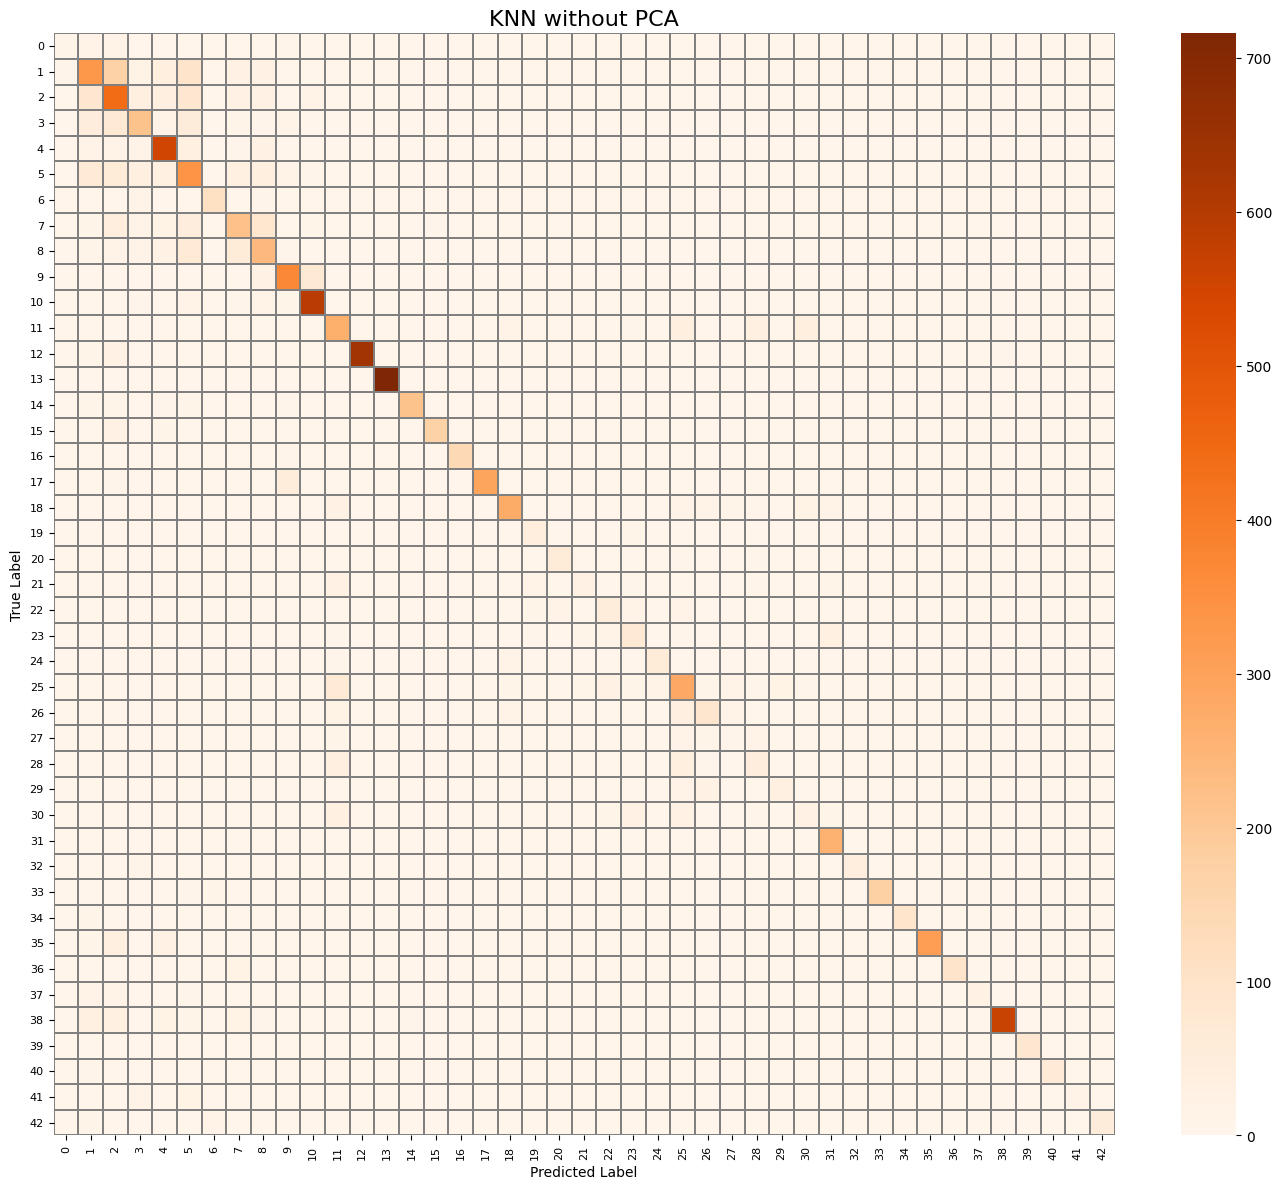

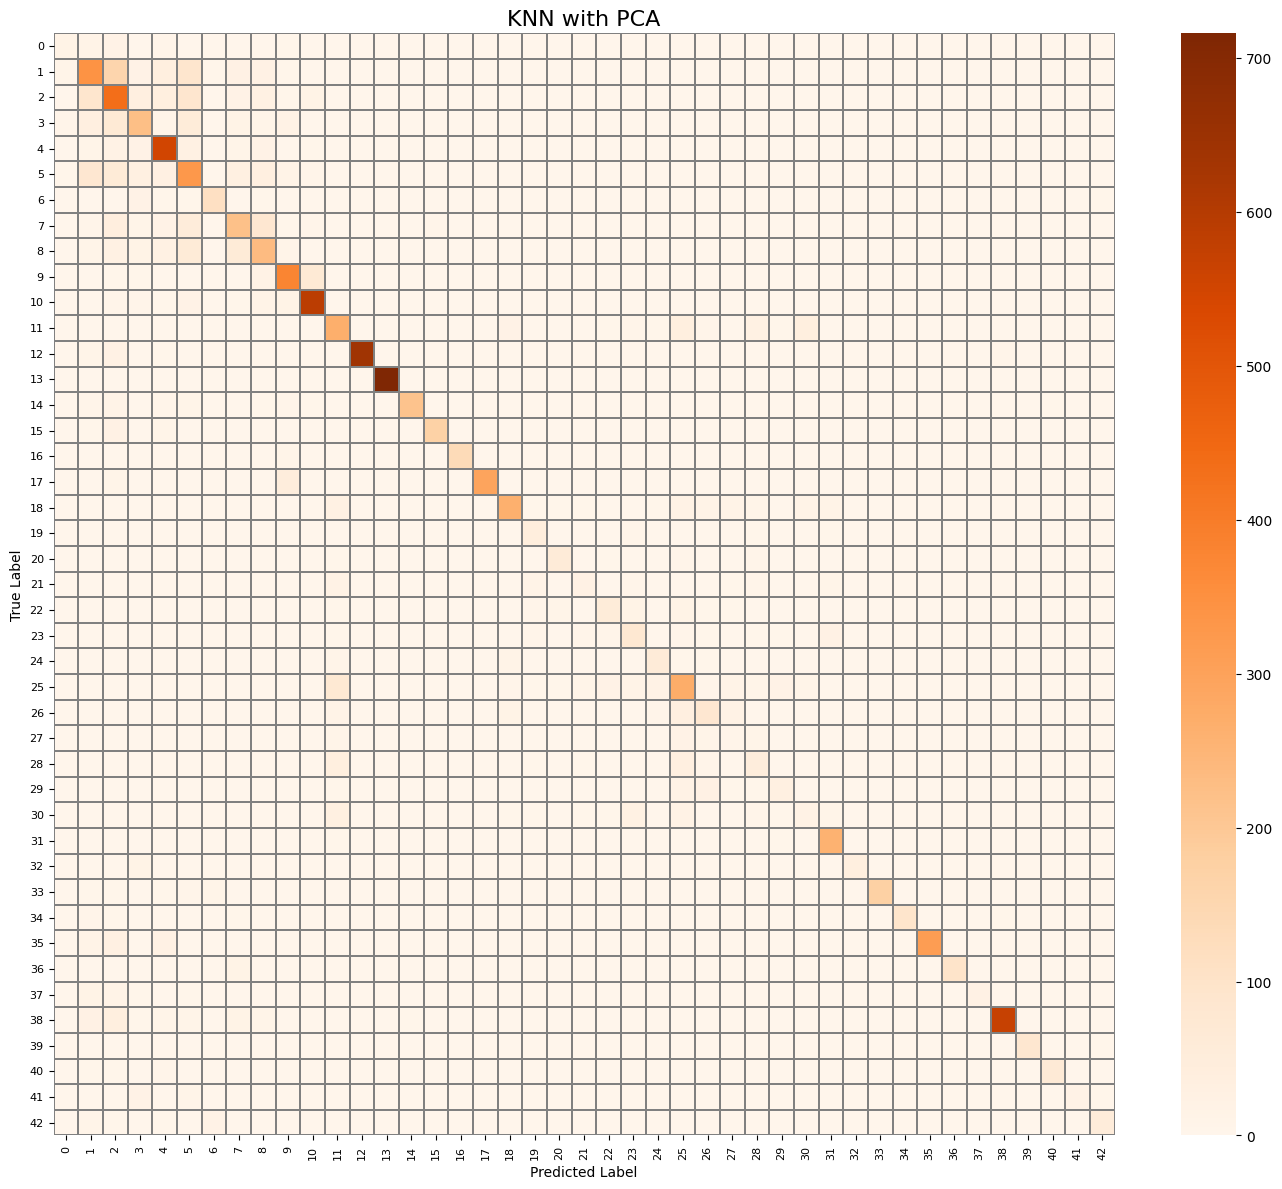

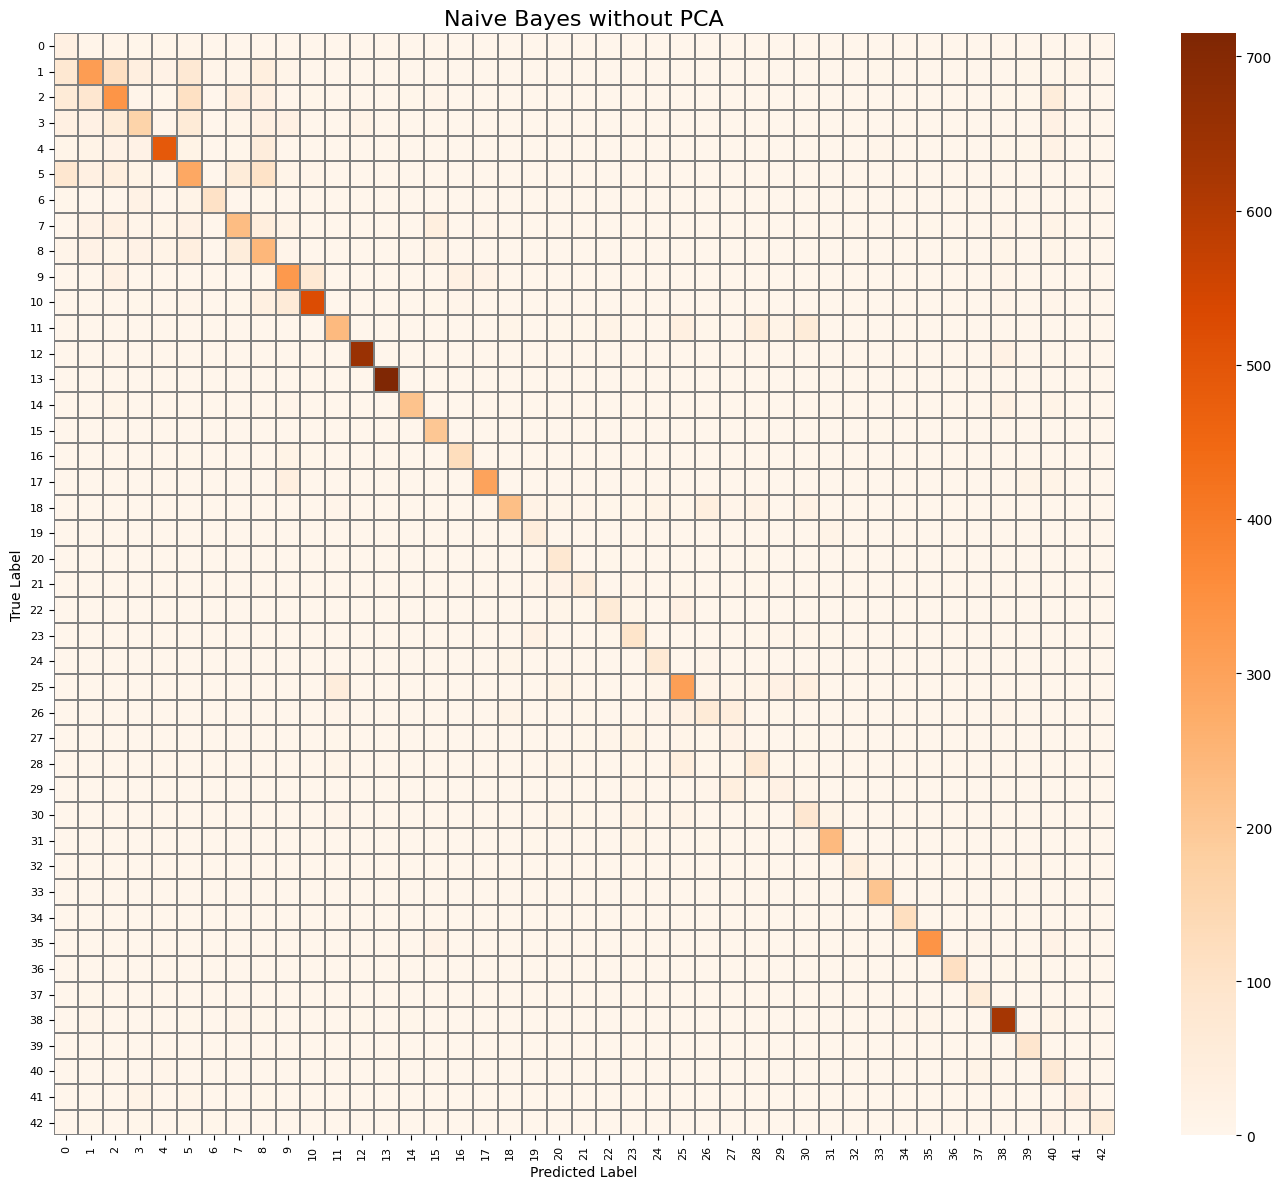

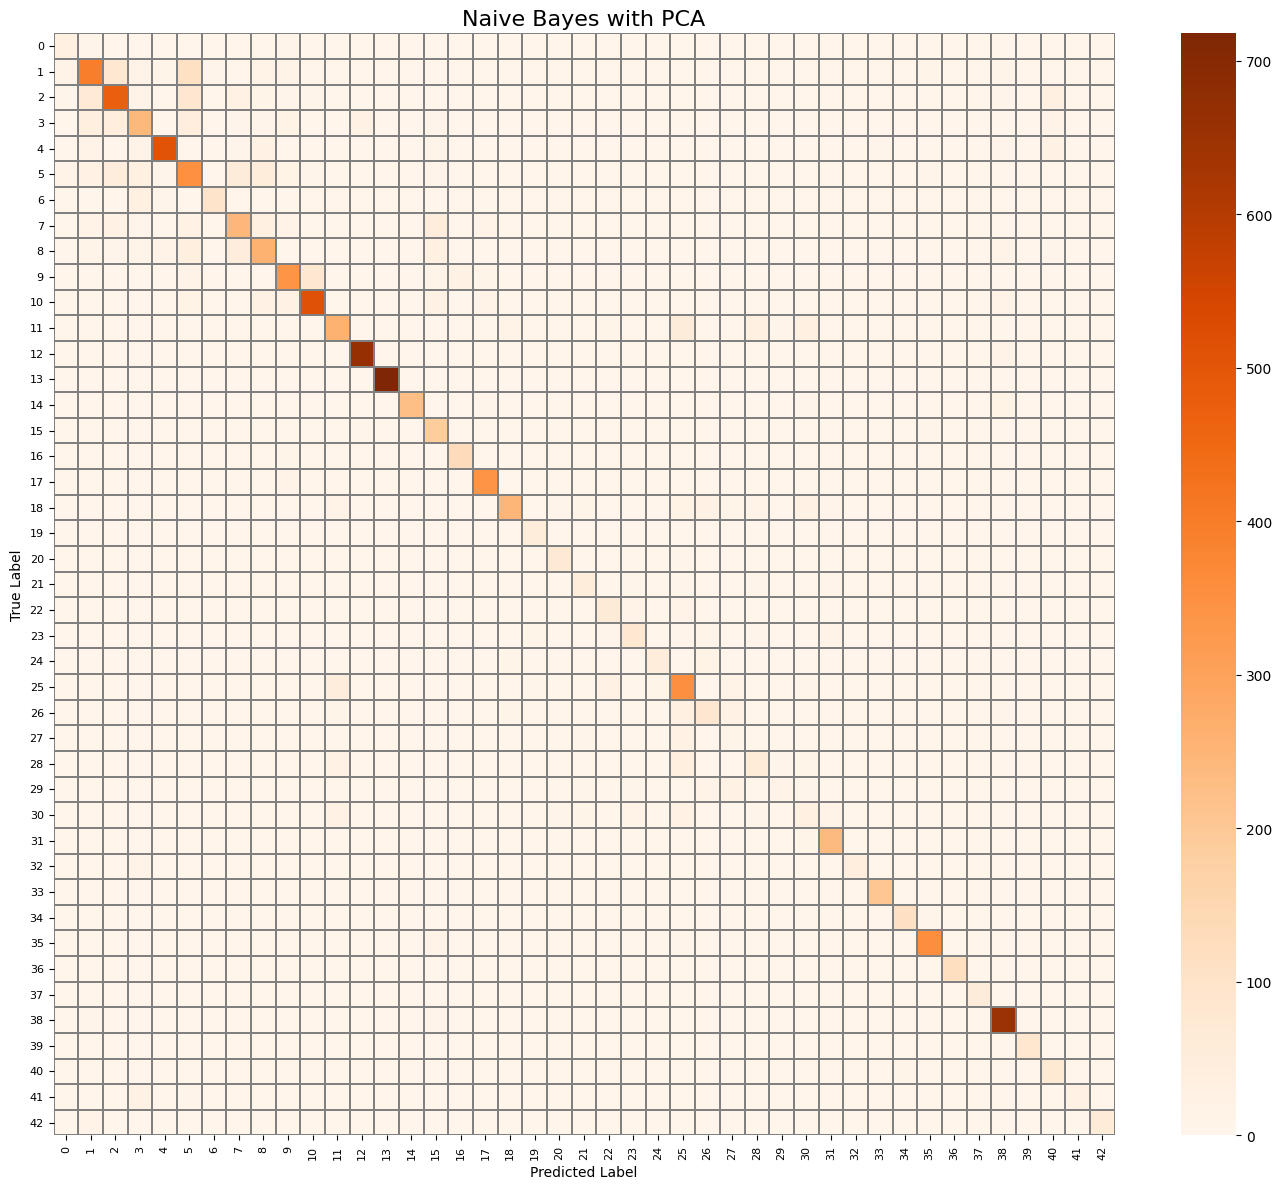

In [ ]:

plot_confusion(y_test, y_KNN_test,     "KNN without PCA")
plot_confusion(y_test, y_KNN_pca_test, "KNN with PCA")
plot_confusion(y_test, y_NB_test,      "Naive Bayes without PCA")
plot_confusion(y_test, y_NB_pca_test,  "Naive Bayes with PCA")

In [ ]:
from multiprocessing import Pool

def load_single(fp, size):
    img = Image.open(fp).resize(size)
    img_array = np.array(img)

    if img_array.ndim == 2:
        img_array = np.stack([img_array] * 3, axis=-1)

    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    return img_array

def load_images(df, size=(32, 32)):
    with Pool() as p:
        images = p.starmap(load_single, [(fp, size) for fp in df['filepath']])
    return np.array(images) / 255.0

x_train_img = load_images(train_df)
x_val_img   = load_images(val_df)
x_test_img  = load_images(test_df)

print(f"Train images : {x_train_img.shape}")
print(f"Val images : {x_val_img.shape}")
print(f"Test images : {x_test_img.shape}")

Train images : (31367, 32, 32, 3)
Val images : (7842, 32, 32, 3)
Test images : (12630, 32, 32, 3)


In [ ]:
def CNN_Model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



def CNN_Deep_Model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



def CNN_K5(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (5,5), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (5,5), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
models_dict = {
    "CNN_Model": CNN_Model(),
    "CNN_Deep_Model": CNN_Deep_Model(),
    "CNN_K5": CNN_K5()
}

h = {}
trained = {}
for name, model in models_dict.items():
    print(f"\nTraining {name} ")

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_img, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(x_test_img, y_test),
        verbose=1
    )

    h[name] = history
    trained[name] = model


Training CNN_Model 
Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.6296 - loss: 1.3489 - val_accuracy: 0.7840 - val_loss: 0.7629
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9405 - loss: 0.2210 - val_accuracy: 0.8877 - val_loss: 0.4896
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9766 - loss: 0.0935 - val_accuracy: 0.9052 - val_loss: 0.4131
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9856 - loss: 0.0587 - val_accuracy: 0.8943 - val_loss: 0.5120
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9887 - loss: 0.0459 - val_accuracy: 0.9095 - val_loss: 0.4527
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9938 - loss: 0.0263 - val_accuracy: 0.9162 - val_loss: 0.4132
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9926 - loss: 0.0283 - val_accuracy: 0.9204 - val_loss: 0.3938
Epoch 8/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9940 - lo

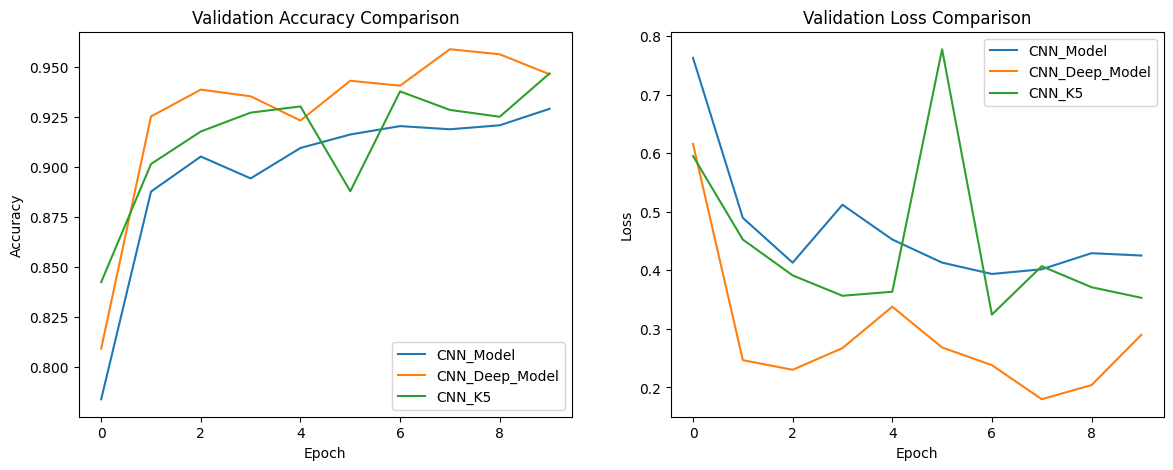

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
for name, x in h.items():
    plt.plot(x.history['val_accuracy'], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
for name, x in h.items():
    plt.plot(x.history['val_loss'], label=name)
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Best Model: CNN_Deep_Model
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step


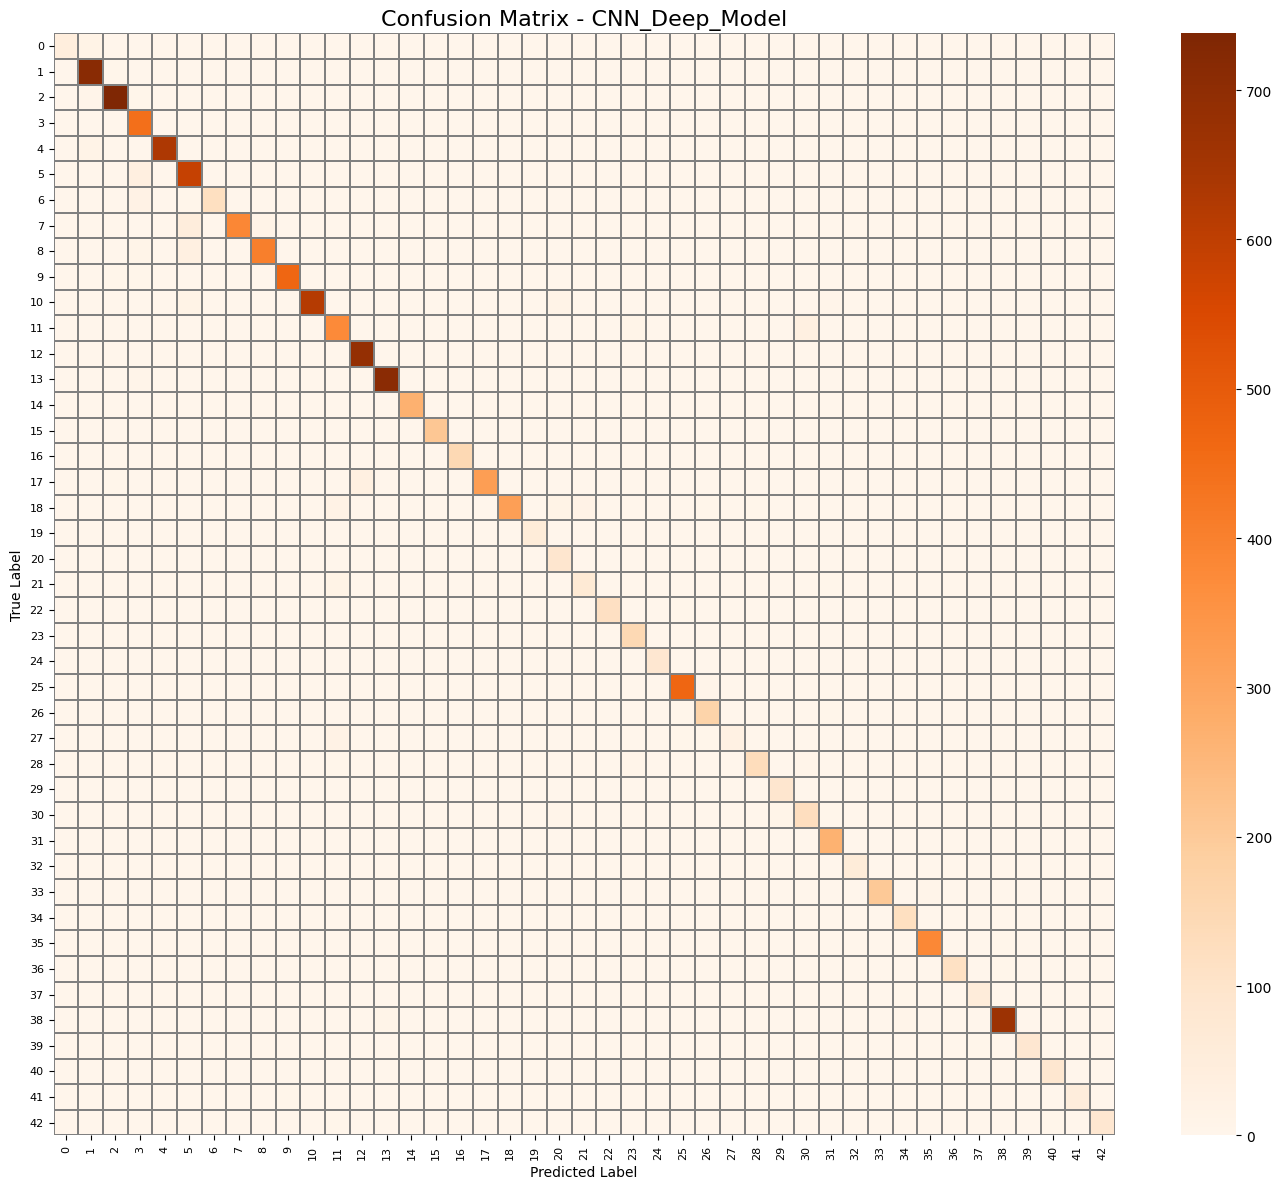

In [ ]:
best_model_name = max(h, key=lambda x: max(h[x].history['val_accuracy']))
best_model = trained[best_model_name]

print("Best Model:", best_model_name)

y_pred = best_model.predict(x_test_img)
y_pred_classes = np.argmax(y_pred, axis=1)

plot_confusion(
    y_test,
    y_pred_classes,
    f"Confusion Matrix - {best_model_name}"
)

In [ ]:
def build_cnn(num_classes=43):
    model = models.Sequential()
    optimizer = keras.optimizers.Adam(learning_rate=0.001)

    # first block
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                             padding='same', input_shape=(32, 32, 3)))
    model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                             padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    # second block
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu',
                             padding='same'))
    model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu',
                             padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    # third block
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu',
                              padding='same'))
    model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu',
                              padding='same'))
    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))


    return model

model = build_cnn()
model.summary()

/home/engshadow/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 331,083 (1.26 MB)

 Trainable params: 331,083 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
histories_cnn = {}

for name, optimizer in [
    ('Adam', keras.optimizers.Adam()),
    ('SGD',  keras.optimizers.SGD(0.01, momentum=0.9))
]:
    m = build_cnn()
    m.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

    hist = m.fit(
        x_train_img, y_train,
        epochs=40,
        batch_size=64,
        validation_data=(x_val_img, y_val),
        verbose=1
    )
    histories_cnn[name] = (m, hist)

    test_loss, test_acc = m.evaluate(x_test_img, y_test, verbose=0)
    print(f"\nCNN ({name}) Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")


Epoch 1/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - accuracy: 0.1790 - loss: 2.8348 - val_accuracy: 0.3804 - val_loss: 1.8720
Epoch 2/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5619 - loss: 1.2782 - val_accuracy: 0.7482 - val_loss: 0.7186
Epoch 3/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8630 - loss: 0.4231 - val_accuracy: 0.9373 - val_loss: 0.2145
Epoch 4/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9487 - loss: 0.1669 - val_accuracy: 0.9693 - val_loss: 0.1055
Epoch 5/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9734 - loss: 0.0886 - val_accuracy: 0.9671 - val_loss: 0.1051
Epoch 6/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9813 - loss: 0.0632 - val_accuracy: 0.9815 - val_loss: 0.0677
Epoch 7/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9846 - loss: 0.0484 - val_accuracy: 0.9430 - val_loss: 0.1807
Epoch 8/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9903 - loss: 0.0330 - val_acc

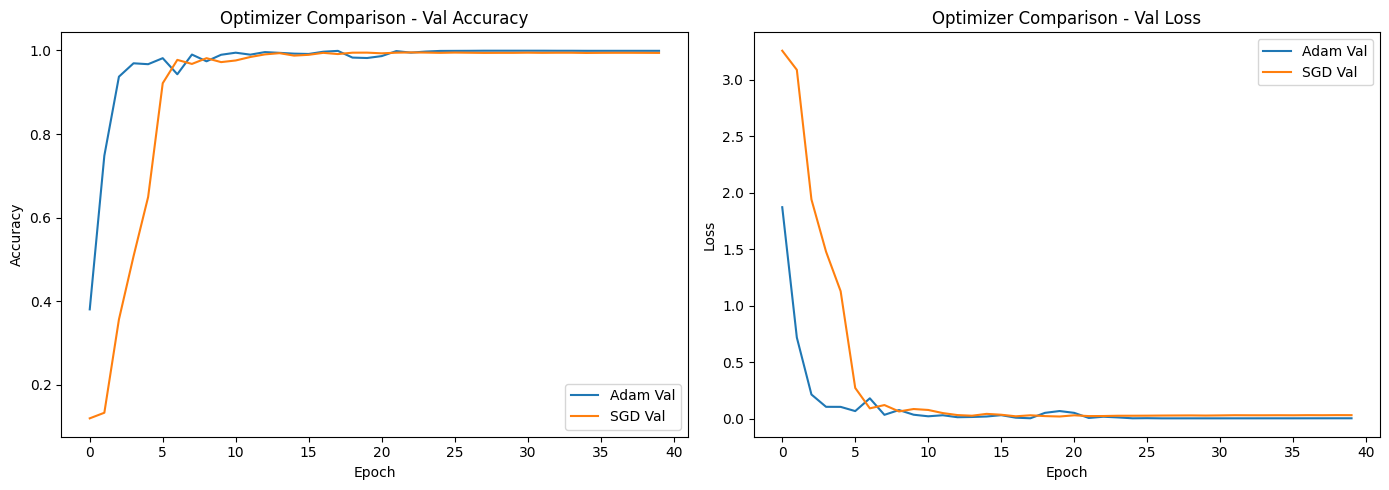

: 

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, (_, h) in histories_cnn.items():
    plt.plot(h.history['val_accuracy'], label=f'{name} Val')
plt.title('Optimizer Comparison - Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
for name, (_, h) in histories_cnn.items():
    plt.plot(h.history['val_loss'], label=f'{name} Val')
plt.title('Optimizer Comparison - Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:


def gaussian_noise(images, noise_factor=0.3):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0., 1.)

def salt_pepper(images, dropout_rate=0.1):
    noisy = np.copy(images)
    mask  = np.random.binomial(1, 1 - dropout_rate, size=images.shape)
    return noisy * mask

x_train_noisy = gaussian_noise(x_train_img, noise_factor=0.2)
x_train_noisy = salt_pepper(x_train_noisy, dropout_rate=0.1)

x_val_noisy   = gaussian_noise(x_val_img, noise_factor=0.2)
x_val_noisy   = salt_pepper(x_val_noisy, dropout_rate=0.1)

x_test_noisy = gaussian_noise(x_test_img, noise_factor=0.2)
x_test_noisy = salt_pepper(x_test_noisy, dropout_rate=0.1)


print(f"Noisy train shape : {x_train_noisy.shape}")
print(f"Noisy val shape : {x_val_noisy.shape}")
print(f"Noisy test shape : {x_test_noisy.shape}")

Noisy train shape : (31367, 32, 32, 3)
Noisy val shape : (7842, 32, 32, 3)
Noisy test shape : (12630, 32, 32, 3)


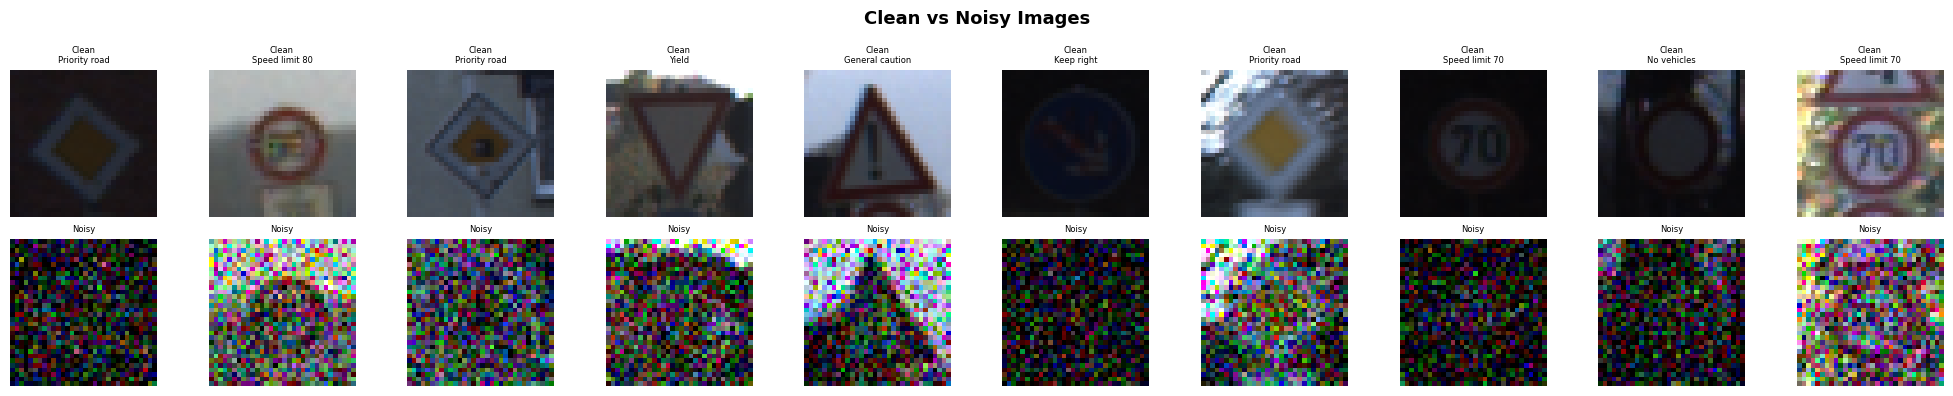

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(x_train_img[i])
    axes[0, i].set_title(f"Clean\n{CLASS_NAMES[y_train[i]]}", fontsize=6)
    axes[0, i].axis('off')

    axes[1, i].imshow(x_train_noisy[i])
    axes[1, i].set_title("Noisy", fontsize=6)
    axes[1, i].axis('off')

plt.suptitle('Clean vs Noisy Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
def build_cnn_autoencoder(input_shape=(32, 32, 3)):
    inputs = layers.Input(shape=input_shape)

    # ENCODER
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D(2, 2)(x)             #(bottleneck)

    # DECODER
    x = layers.Conv2DTranspose(128, (3,3), activation='relu',
                                strides=2, padding='same')(encoded)
    x = layers.Conv2DTranspose(64,  (3,3), activation='relu',
                                strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32,  (3,3), activation='relu',
                                strides=2, padding='same')(x)

    decoded = layers.Conv2D(3, (3,3), activation='sigmoid',
                             padding='same')(x)

    autoencoder = keras.Model(inputs, decoded, name='cnn_autoencoder')
    return autoencoder

autoencoder = build_cnn_autoencoder()
autoencoder.summary()


# Compile the model
autoencoder.compile(
    optimizer='adam',
    loss='mse',
)

Model: "cnn_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ae = autoencoder.fit(
    x_train_noisy, x_train_img,
    epochs=40,
    batch_size=32,
    shuffle=True,
    validation_data=(x_val_noisy, x_val_img),
    verbose=1
)

Epoch 1/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - loss: 0.0162 - val_loss: 0.0105
Epoch 2/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0083 - val_loss: 0.0075
Epoch 3/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0068 - val_loss: 0.0065
Epoch 4/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 5/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 6/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 7/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 8/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 9/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0045 - val_loss: 0.0046
Epoch 10/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 11/40
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 12/40
981/981 ━━━━━━━━━━

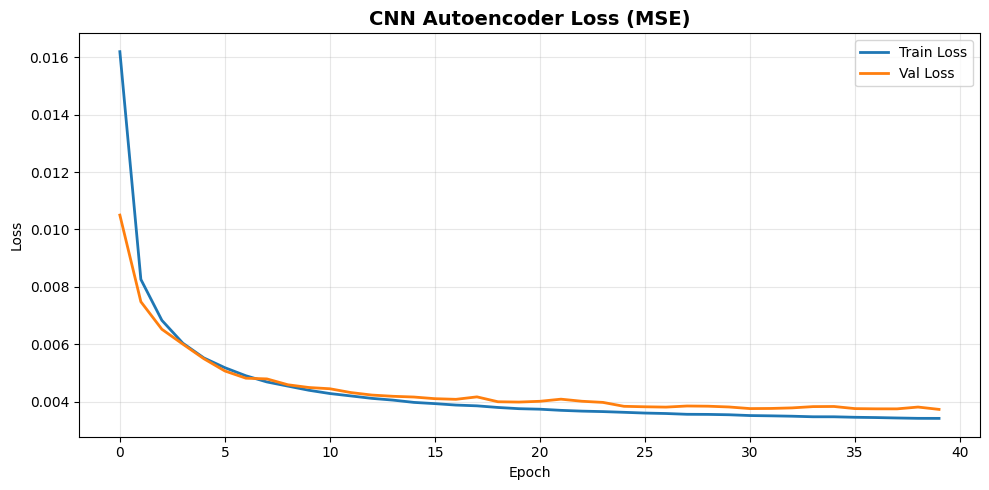

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_ae.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history_ae.history['val_loss'], label='Val Loss',   linewidth=2)
plt.title('CNN Autoencoder Loss (MSE)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Generating reconstructed features
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


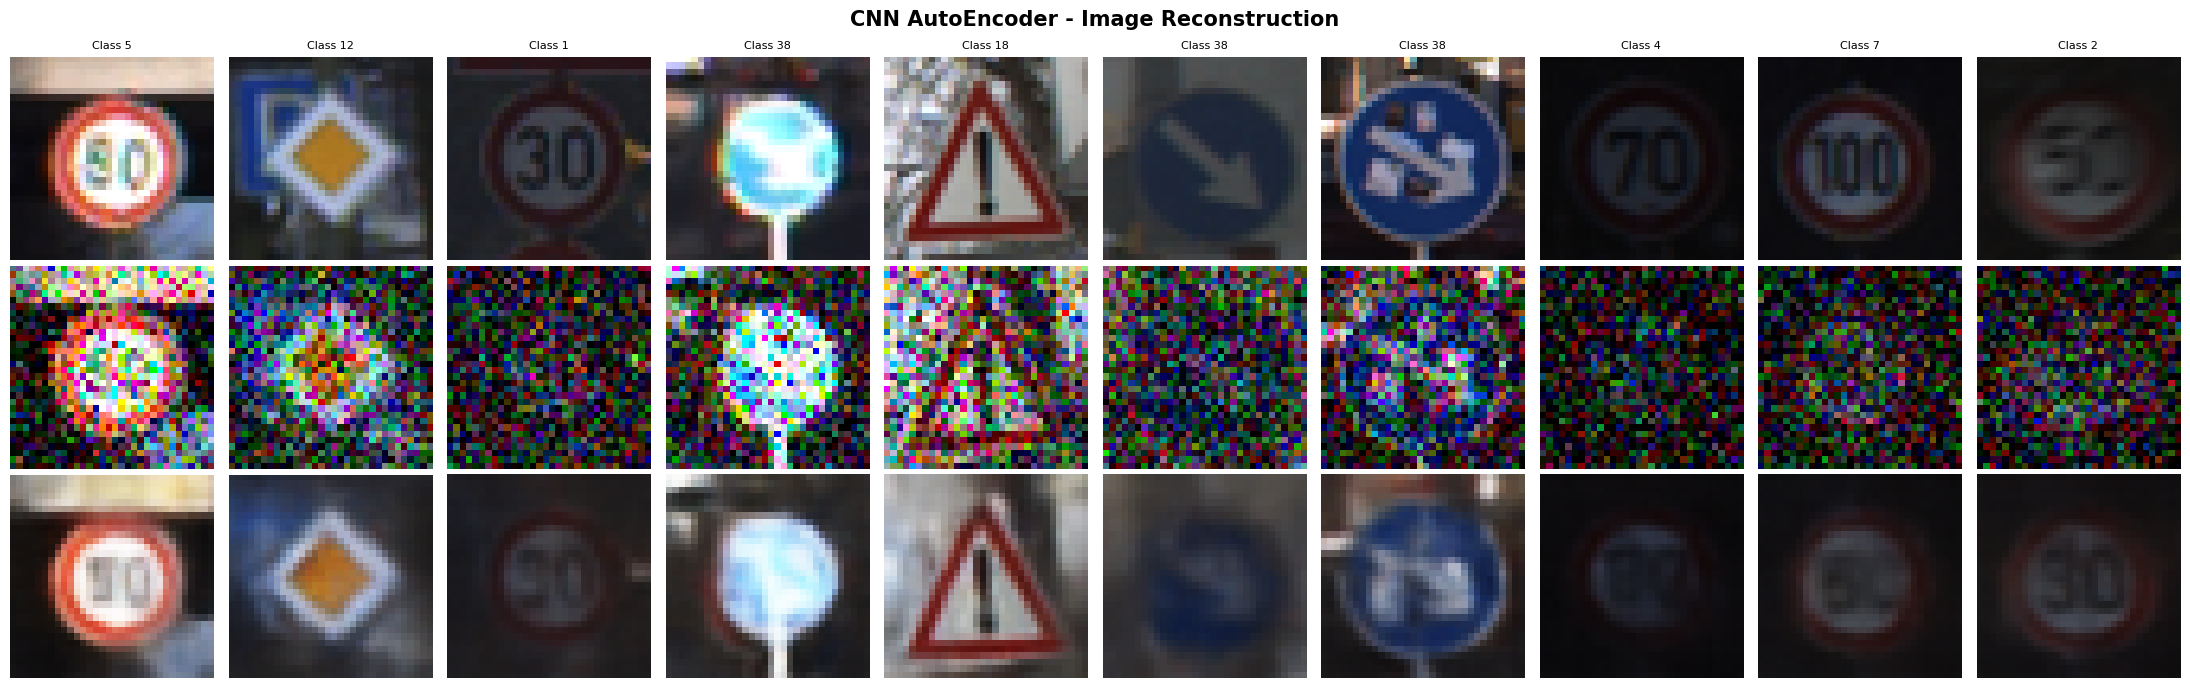

In [ ]:
print("\nGenerating reconstructed features")

x_train_reconstructed = autoencoder.predict(x_train_noisy)
x_val_reconstructed   = autoencoder.predict(x_val_noisy)
x_test_reconstructed  = autoencoder.predict(x_test_noisy)

n_samples = 10
sample_indices = np.random.choice(len(x_test_img), n_samples, replace=False)

fig, axes = plt.subplots(3, n_samples, figsize=(22, 7))

for i, idx in enumerate(sample_indices):
    # Clean images
    axes[0, i].imshow(x_test_img[idx])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Clean',
                               fontsize=10, fontweight='bold')

    # Noisy images
    axes[1, i].imshow(x_test_noisy[idx])
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Noisy',
                               fontsize=10, fontweight='bold')

    # Reconstructed images
    axes[2, i].imshow(x_test_reconstructed[idx])
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Reconstructed',
                               fontsize=10, fontweight='bold')

    axes[0, i].set_title(f'Class {y_test[idx]}', fontsize=8)

plt.suptitle('CNN AutoEncoder - Image Reconstruction',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
mse_train = np.mean((x_train_img - x_train_reconstructed) ** 2)
mse_val   = np.mean((x_val_img   - x_val_reconstructed)   ** 2)
mse_test  = np.mean((x_test_img  - x_test_reconstructed)  ** 2)

print(f"\n{'='*60}")
print(f"CNN AUTOENCODER - Image Reconstruction Performance")
print(f"{'='*60}")
print(f"Train MSE : {mse_train:.6f}")
print(f"Val   MSE : {mse_val:.6f}")
print(f"Test  MSE : {mse_test:.6f}")
print(f"{'='*60}")


CNN AUTOENCODER - Image Reconstruction Performance
Train MSE : 0.003394
Val   MSE : 0.003729
Test  MSE : 0.003880


In [ ]:
import joblib
import json

# Paths
base_path = ""
model_path = os.path.join(base_path, "models")
os.makedirs(model_path, exist_ok=True)

# 1. Save Autoencoder Model
autoencoder.save(os.path.join(model_path, "autoencoder.h5"))

# 2. Save Encoder Only (Feature Extractor)
encoder = keras.Model(autoencoder.input, autoencoder.layers[3].output)
encoder.save(os.path.join(model_path, "encoder.h5"))

# 3. Save Scaler
joblib.dump(scaler, os.path.join(model_path, "scaler.pkl"))

# 4. Save Reconstructed Features
features_path = os.path.join(base_path, "features")

np.save(os.path.join(features_path, "x_train_reconstructed.npy"), x_train_reconstructed)
np.save(os.path.join(features_path, "x_test_reconstructed.npy"), x_test_reconstructed)

# 5. Save Noisy Data
np.save(os.path.join(features_path, "x_train_noisy.npy"), x_train_noisy)
np.save(os.path.join(features_path, "x_test_noisy.npy"), x_test_noisy)

# 6. Save Training History
with open(os.path.join(base_path, "history.json"), "w") as f:
    json.dump(history_ae.history, f)

# 7. Save Metrics
with open(os.path.join(base_path, "results.txt"), "w") as f:
    f.write(f"Train MSE: {mse_train}\n")
    f.write(f"Test MSE: {mse_test}\n")

print("All new components saved successfully!")

All new components saved successfully!


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model, callbacks
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import accuracy_score


IMG_SIZE = (96, 96)
BATCH_SIZE = 64



train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True
)

val_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

test_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)


Found 31367 validated image filenames.
Found 7842 validated image filenames.
Found 12630 validated image filenames.


In [ ]:
import gc


def build_mobilenet(input_shape=(96, 96, 3), num_classes=43):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = True

    for layer in base_model.layers[-20:]:
        layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    tf.keras.backend.clear_session()
    gc.collect()

    return Model(inputs, outputs), base_model

model, base_model = build_mobilenet()
model.summary()





Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 2,393,387 (9.13 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_df['label'].values[:len(y_pred)]

final_acc = accuracy_score(y_true, y_pred)
print(f"\nFinal Test Accuracy: {final_acc:.4f}")

print(f"Final Accuracy: {accuracy_score(y_true, y_pred):.4f}")

197/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

I0000 00:00:1776639005.306506   41955 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


198/198 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step

Final Test Accuracy: 0.7192
Final Accuracy: 0.7192


In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print ("Training (frozen base + last-20 unfrozen) ")
history_frozen = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Training (frozen base + last-20 unfrozen) 
Epoch 1/8
491/491 ━━━━━━━━━━━━━━━━━━━━ 2040s 4s/step - accuracy: 0.8593 - loss: 0.5155 - val_accuracy: 0.1520 - val_loss: 7.1782 - learning_rate: 0.0010
Epoch 2/8
491/491 ━━━━━━━━━━━━━━━━━━━━ 1851s 4s/step - accuracy: 0.9670 - loss: 0.1277 - val_accuracy: 0.3124 - val_loss: 6.6439 - learning_rate: 0.0010
Epoch 3/8
491/491 ━━━━━━━━━━━━━━━━━━━━ 1842s 4s/step - accuracy: 0.9744 - loss: 0.1018 - val_accuracy: 0.5029 - val_loss: 3.5974 - learning_rate: 0.0010
Epoch 4/8
491/491 ━━━━━━━━━━━━━━━━━━━━ 1686s 3s/step - accuracy: 0.9809 - loss: 0.0771 - val_accuracy: 0.8606 - val_loss: 0.7412 - learning_rate: 0.0010
Epoch 5/8
491/491 ━━━━━━━━━━━━━━━━━━━━ 1587s 3s/step - accuracy: 0.9808 - loss: 0.0794 - val_accuracy: 0.6251 - val_loss: 2.7279 - learning_rate: 0.0010
Epoch 6/8
491/491 ━━━━━━━━━━━━━━━━━━━━ 1628s 3s/step - accuracy: 0.9870 - loss: 0.0533 - val_accuracy: 0.8053 - val_loss: 1.2632 - learning_rate: 0.0010


In [ ]:
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_df['label'].values[:len(y_pred)]

final_acc = accuracy_score(y_true, y_pred)
print(f"\nFinal Test Accuracy: {final_acc:.4f}")

198/198 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step

Final Test Accuracy: 0.8126


In [ ]:
import json
with open("mobilenet_results/history.json", "w") as f:
    json.dump(history_frozen.history, f)

model.save("mobilenet_results/mobilenet_traffic.keras")
np.save( "mobilenet_results/y_pred_mobilenet.npy", y_pred)
np.save( "mobilenet_results/y_pred_probs_mobilenet.npy", y_pred_probs)
np.save( "mobilenet_results/y_true_mobilenet.npy", y_true)


In [ ]:
def prepare_data_for_gru(images):

    return images.reshape(images.shape[0], images.shape[1], -1)

x_train_gru = prepare_data_for_gru(x_train_img)
x_val_gru   = prepare_data_for_gru(x_val_img)
x_test_gru  = prepare_data_for_gru(x_test_img)

In [ ]:
def build_gru_model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 96)),
        layers.GRU(64, return_sequences=True),
        layers.BatchNormalization(),
        layers.GRU(64, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

gru_model = build_gru_model()


In [ ]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining GRU Model")
history_gru = gru_model.fit(
    x_train_gru, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val_gru, y_val),
    verbose=1
)



Training GRU Model...
Epoch 1/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 46s 68ms/step - accuracy: 0.2366 - loss: 2.7112 - val_accuracy: 0.3889 - val_loss: 1.9746
Epoch 2/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 31s 72ms/step - accuracy: 0.5258 - loss: 1.4997 - val_accuracy: 0.6439 - val_loss: 1.1315
Epoch 3/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.6829 - loss: 0.9998 - val_accuracy: 0.7141 - val_loss: 0.9141
Epoch 4/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.7801 - loss: 0.7022 - val_accuracy: 0.7765 - val_loss: 0.7092
Epoch 5/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.8425 - loss: 0.5133 - val_accuracy: 0.8661 - val_loss: 0.4310
Epoch 6/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.8794 - loss: 0.3932 - val_accuracy: 0.8908 - val_loss: 0.3586
Epoch 7/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9000 - loss: 0.3307 - val_accuracy: 0.8816 - val_loss: 0.3961
Epoch 8/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0

In [ ]:
y_pred_gru_probs = gru_model.predict(x_test_gru)
y_pred_gru = np.argmax(y_pred_gru_probs, axis=1)

gru_acc = accuracy_score(y_test, y_pred_gru)
print(f"\nGRU Test Accuracy: {gru_acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step

GRU Test Accuracy: 0.8863


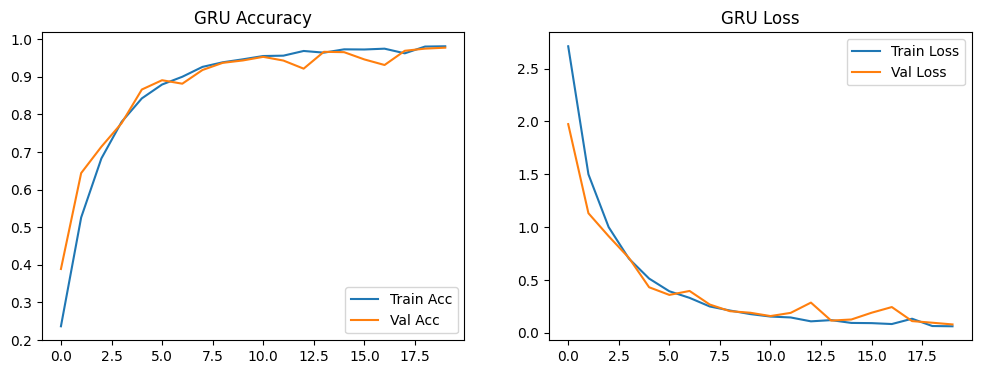

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_gru.history['accuracy'], label='Train Acc')
plt.plot(history_gru.history['val_accuracy'], label='Val Acc')
plt.title('GRU Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('GRU Loss')
plt.legend()
plt.show()



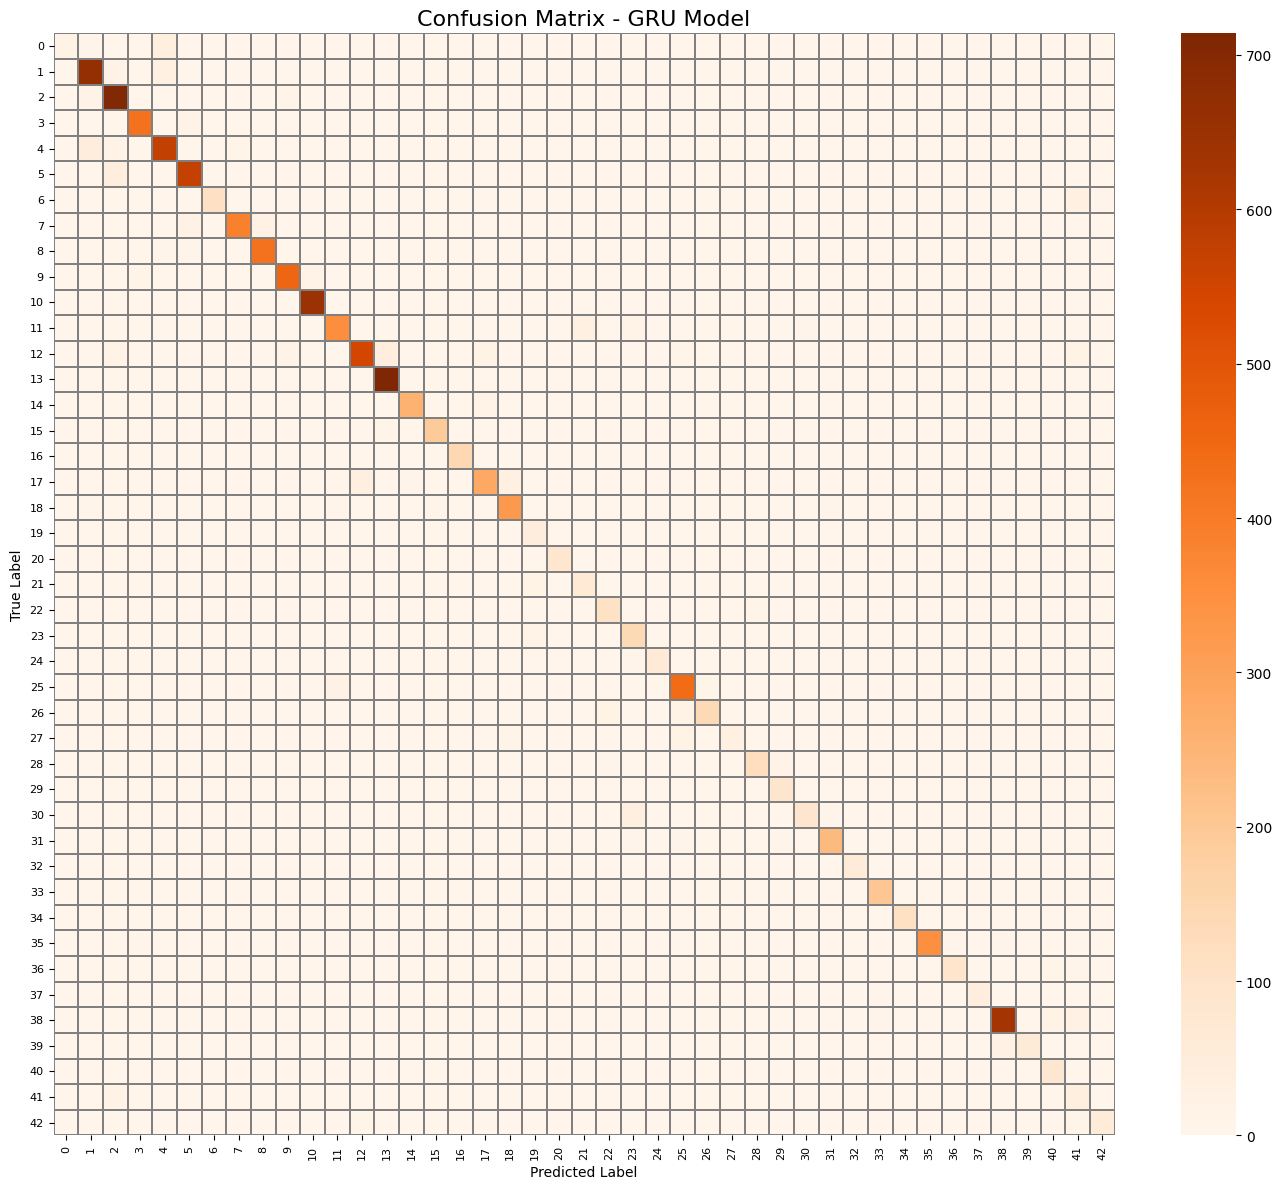

In [ ]:
plot_confusion(y_test, y_pred_gru, "Confusion Matrix - GRU Model")

In [ ]:
def build_rnn_model(num_classes=43):
    model = models.Sequential([
        layers.Input(shape=(32, 96)),
        layers.SimpleRNN(64, return_sequences=True),
        layers.BatchNormalization(),
        layers.SimpleRNN(64, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

rnn_model = build_rnn_model()

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining Simple RNN Model")
history_rnn = rnn_model.fit(
    x_train_gru, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_val_gru, y_val),
    verbose=1
)

I0000 00:00:1778414602.729320      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778414602.735426      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Training Simple RNN Model
Epoch 1/20


I0000 00:00:1778414608.137639     160 service.cc:152] XLA service 0x7852e00157d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778414608.137691     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778414608.137699     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778414608.649804     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


 24/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0401 - loss: 3.7574

I0000 00:00:1778414610.856001     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


491/491 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.2073 - loss: 2.9338 - val_accuracy: 0.5278 - val_loss: 1.5404
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5723 - loss: 1.4102 - val_accuracy: 0.7072 - val_loss: 0.9589
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6956 - loss: 0.9891 - val_accuracy: 0.7289 - val_loss: 0.8669
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7537 - loss: 0.7929 - val_accuracy: 0.7649 - val_loss: 0.7744
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7878 - loss: 0.6988 - val_accuracy: 0.8264 - val_loss: 0.5823
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8194 - loss: 0.5985 - val_accuracy: 0.8192 - val_loss: 0.5822
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8397 - loss: 0.5359 - val_accuracy: 0.8273 - val_loss: 0.5835
Epoch 8/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8509 - loss: 0.4949 - val_accuracy: 0.8726 - va

In [ ]:
y_pred_rnn_probs = rnn_model.predict(x_test_gru)
y_pred_rnn = np.argmax(y_pred_rnn_probs, axis=1)
rnn_acc = accuracy_score(y_test, y_pred_rnn)
print(f"\nSimple RNN Test Accuracy: {rnn_acc:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Simple RNN Test Accuracy: 0.8079


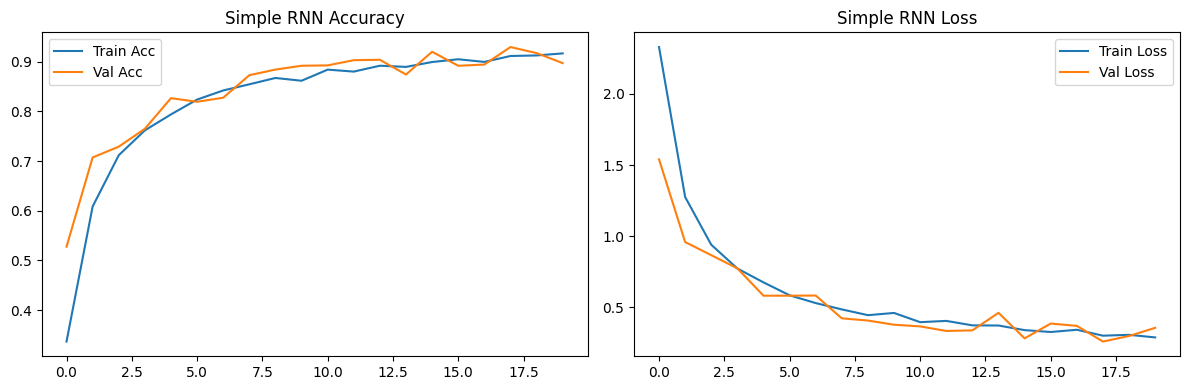

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Train Acc')
plt.plot(history_rnn.history['val_accuracy'], label='Val Acc')
plt.title('Simple RNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('Simple RNN Loss')
plt.legend()
plt.tight_layout()
plt.show()

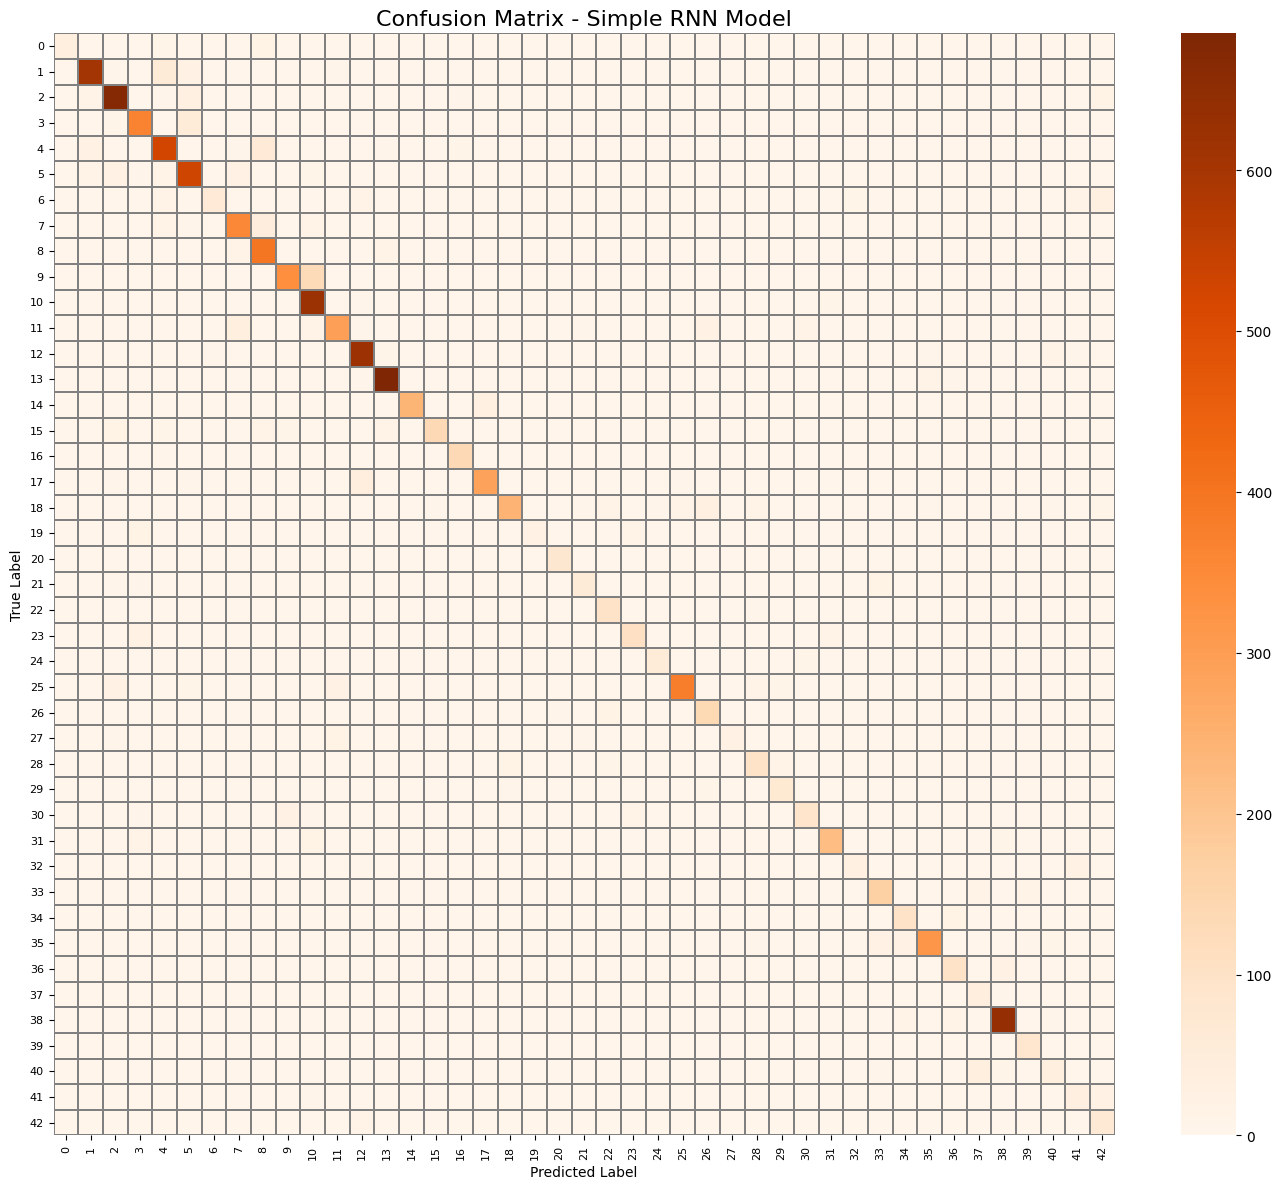

In [ ]:
plot_confusion(y_test, y_pred_rnn, "Confusion Matrix - Simple RNN Model")

In [10]:
!pip install transformers -q

In [8]:
# =========================
# Vision Transformer (ViT) - Fine-tuning on GTSRB
# Colab + Google Drive version
# Uses existing:
#   train_df, val_df, test_df, CLASS_NAMES
# =========================


import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm

from transformers import ViTImageProcessor, ViTForImageClassification


# -------------------------
# Define device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------
# Reuse existing class names
# -------------------------
id2label = CLASS_NAMES
label2id = {v: k for k, v in CLASS_NAMES.items()}

# Make sure labels are ints
train_df["label"] = train_df["label"].astype(int)
val_df["label"]   = val_df["label"].astype(int)
test_df["label"]  = test_df["label"].astype(int)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

# -------------------------
# Hugging Face image processor
# -------------------------
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

# -------------------------
# Dataset class
# -------------------------
class TrafficSignViTDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")
        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# -------------------------
# Datasets and loaders
# -------------------------
train_dataset_vit = TrafficSignViTDataset(train_df, processor)
val_dataset_vit   = TrafficSignViTDataset(val_df, processor)
test_dataset_vit  = TrafficSignViTDataset(test_df, processor)

# Reduce batch size if you hit RAM/VRAM issues
BATCH_SIZE = 8

train_loader_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE, shuffle=True)
val_loader_vit   = DataLoader(val_dataset_vit, batch_size=BATCH_SIZE, shuffle=False)
test_loader_vit  = DataLoader(test_dataset_vit, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader_vit))
print("Val batches:", len(val_loader_vit))
print("Test batches:", len(test_loader_vit))

# -------------------------
# Load pretrained ViT
# -------------------------
model_vit = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=43,
    id2label=id2label,
    label2id={str(k): v for k, v in id2label.items()},
    ignore_mismatched_sizes=True
).to(device)

optimizer = AdamW(model_vit.parameters(), lr=2e-5)

# -------------------------
# Save paths on Google Drive
# -------------------------
save_dir = "/content/drive/MyDrive/ai_project_v/vit_checkpoint_files"
os.makedirs(save_dir, exist_ok=True)

checkpoint_path = os.path.join(save_dir, "vit_checkpoint.pth")
final_model_dir = os.path.join(save_dir, "vit_final_model")

# -------------------------
# Resume if checkpoint exists
# -------------------------
start_epoch = 0
train_losses_vit = []
val_accuracies_vit = []

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_vit.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    train_losses_vit = checkpoint["train_losses"]
    val_accuracies_vit = checkpoint["val_accuracies"]
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found. Starting from scratch.")

# -------------------------
# Training function
# num_new_epochs lets you do 5 now, 5 later
# -------------------------
def train_vit(model, train_loader, val_loader, optimizer, start_epoch, num_new_epochs):
    global train_losses_vit, val_accuracies_vit

    for epoch in range(start_epoch, start_epoch + num_new_epochs):
        model.train()
        total_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for batch in progress_bar:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix(loss=float(loss.item()))

        avg_loss = total_loss / len(train_loader)
        train_losses_vit.append(avg_loss)

        # Validation
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                pixel_values = batch["pixel_values"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(pixel_values=pixel_values)
                preds = torch.argmax(outputs.logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        val_accuracies_vit.append(val_acc)

        print(f"Epoch [{epoch+1}] | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}")

        # Save checkpoint after every epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses_vit,
            "val_accuracies": val_accuracies_vit
        }, checkpoint_path)

        print(f"Checkpoint saved: epoch {epoch+1}")

# -------------------------
# Run training
# Set to 5 now, then run again later for another 5
# -------------------------
NUM_NEW_EPOCHS = 5

train_vit(
    model=model_vit,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    optimizer=optimizer,
    start_epoch=start_epoch,
    num_new_epochs=NUM_NEW_EPOCHS
)

Using device: cuda
Train samples: 31367
Val samples: 7842
Test samples: 12630


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Train batches: 3921
Val batches: 981
Test batches: 1579


config.json: 0.00B [00:00, ?B/s]

...

Epoch [3] | Loss: 0.0073 | Val Accuracy: 0.9989
Checkpoint saved: epoch 3


Epoch 4:   0%|          | 0/3921 [00:00<?, ?it/s]

Epoch [4] | Loss: 0.0040 | Val Accuracy: 0.9957
Checkpoint saved: epoch 4


Epoch 5:   0%|          | 0/3921 [00:00<?, ?it/s]

Epoch [5] | Loss: 0.0089 | Val Accuracy: 0.9983
Checkpoint saved: epoch 5


In [ ]:
# =========================
# Resume ViT checkpoint from Google Drive
# Run this BEFORE continuing training
# =========================

import os
import torch

# Make sure this path matches where you saved your checkpoint
save_dir = "/content/drive/MyDrive/ai_project_v/vit_checkpoint_files"
checkpoint_path = os.path.join(save_dir, "vit_checkpoint.pth")

start_epoch = 0
train_losses_vit = []
val_accuracies_vit = []

if os.path.exists(checkpoint_path):
    print("Checkpoint found.")
    print("Loading from:", checkpoint_path)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model weights
    model_vit.load_state_dict(checkpoint["model_state_dict"])

    # Load optimizer state
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    # Move optimizer states to GPU if needed
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)

    # Resume epoch and history
    start_epoch = checkpoint["epoch"] + 1
    train_losses_vit = checkpoint["train_losses"]
    val_accuracies_vit = checkpoint["val_accuracies"]

    print(f"Successfully resumed from epoch {start_epoch}")
    print(f"Previous train losses: {train_losses_vit}")
    print(f"Previous val accuracies: {val_accuracies_vit}")

else:
    print("No checkpoint found.")
    print("Training will start from scratch.")

In [ ]:
NUM_NEW_EPOCHS = 5

train_vit(
    model=model_vit,
    train_loader=train_loader_vit,c
    val_loader=val_loader_vit,
    optimizer=optimizer,
    start_epoch=start_epoch,
    num_new_epochs=NUM_NEW_EPOCHS
)


In [9]:
# -------------------------
# Save final model + processor
# -------------------------
os.makedirs(final_model_dir, exist_ok=True)
model_vit.save_pretrained(final_model_dir)
processor.save_pretrained(final_model_dir)

print("Final ViT model and processor saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final ViT model and processor saved successfully!


In [10]:
# -------------------------
# Final test evaluation
# -------------------------
model_vit.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_vit:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_vit(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

vit_test_acc = accuracy_score(all_labels, all_preds)
print(f"\nFinal ViT Test Accuracy: {vit_test_acc:.4f}")




Final ViT Test Accuracy: 0.9884


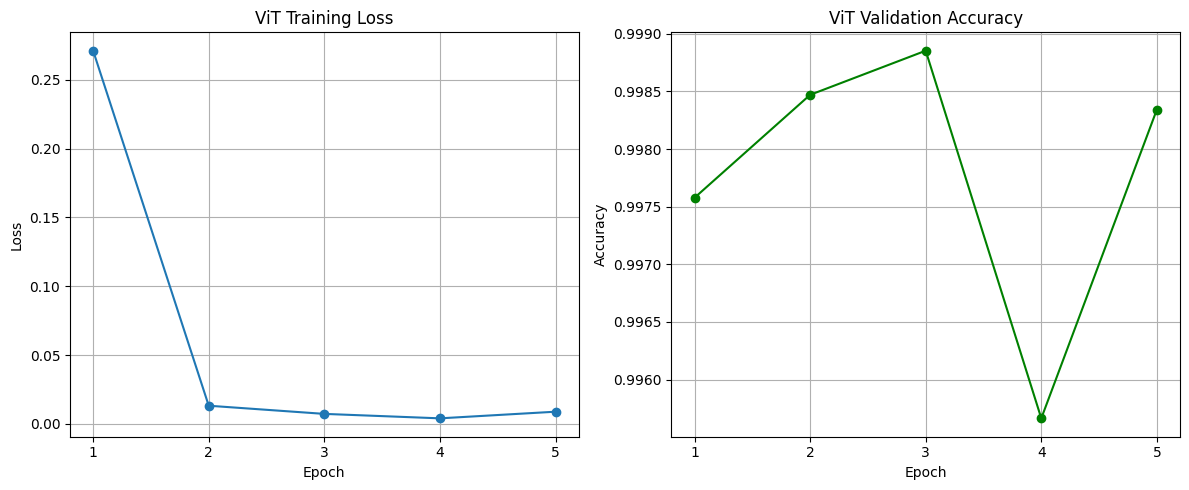

In [13]:
epochs = range(1, len(val_accuracies_vit) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_vit, marker='o')
plt.title("ViT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies_vit, marker='o', color='green')
plt.title("ViT Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.grid(True)

plt.tight_layout()
plt.show()

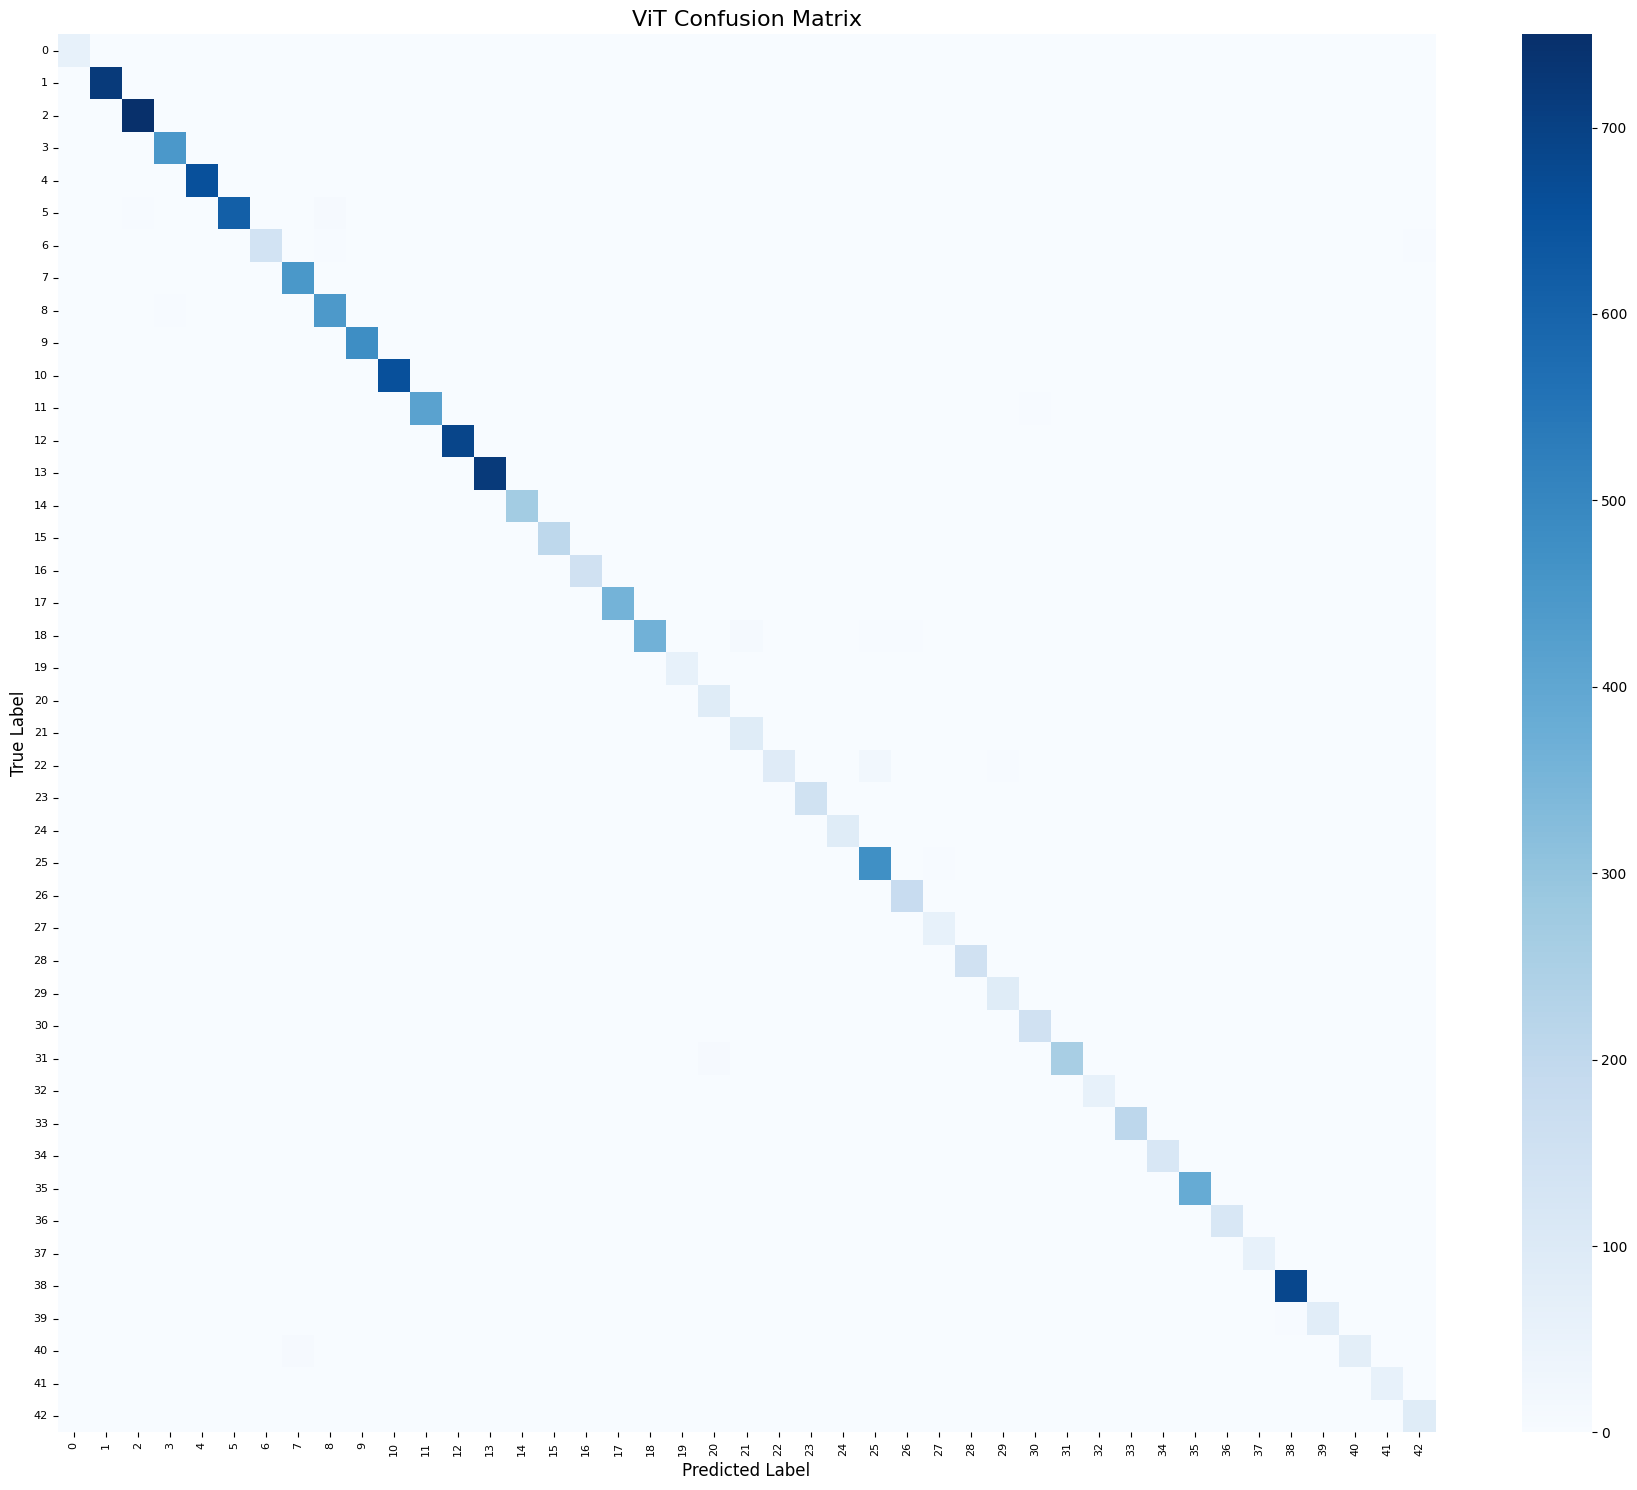

In [14]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=range(43),
    yticklabels=range(43)
)

plt.title("ViT Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()